# What breaks when the controller is random

*Third notebook in the set. `rnn_offmanifold_finding.ipynb` showed a trained GRU drifts off the
data manifold. `analytical_rnn_fsc_wsls.ipynb` solved for a GRU that IS the controller, exactly,
on a deterministic task. This one runs that same construction on a random one, and finds where it
holds and where it cannot.*

## The task

Same two-armed setup as the other notebooks, but the rule generating the data is deliberately
noisy. `rwsls_det_init` is the stochastic control: after a win it stays about 67% of the time
rather than always. Its fitted FSC is stochastic in both halves, a policy of `[0.204, 0.796]` and
transition rows like `[0.25, 0.75]`.

That one change breaks an assumption the previous notebook never had to state.

## What the previous notebook quietly relied on

A deterministic controller is always *definitely* in one memory state. Its belief sits on a corner
of the simplex, every trial, forever. So pinning the network at the $M$ corners pins its entire
trajectory, and "be the machine" has one unambiguous meaning.

Take that away and two things separate that used to be the same thing:

1. **Where the machine goes.** The belief is now usually a mixture like 70/30. It is fully in one
   state on only **18%** of trials. The $M$ corners are no longer the trajectory, they are a
   measure-zero corner of it.
2. **Which update rule you mean.** "Where do I go next" (forward transition) and "where am I now,
   given what I have seen" (Bayesian filtering) are different functions once the policy is
   stochastic. They agree exactly at the corners, which is why the question never arose.

## What this notebook finds

- §2 to §6 run the original construction unchanged. It solves to machine precision and still is
  not the controller: over real sessions its state sits $10^{-2}$ from the FSC's, against
  $10^{-9}$ on the deterministic task. §3.3 measures why.
- §7 repairs it. State the requirement along the whole belief line instead of at its two ends, and
  target the Bayesian posterior. Tracking error drops by about 3500x, to $10^{-6}$, at every
  hidden size including $H = 1$. **The memory transfers exactly.**
- §8 finds the part that does not repair. The FSC's action probability is linear in the belief;
  a softmax readout of a linear embedding is a sigmoid. A line and a sigmoid cannot coincide.
  The error is identical at $H = 1$ and $H = 4$, so it is architectural, not a capacity limit.

The headline: **a GRU can carry a stochastic controller's memory exactly, and cannot report its
action probabilities exactly.** On a deterministic controller the belief only ever visits two
points, a sigmoid matches a line at two points, and the wall was invisible.

## Roadmap

- §0 setup, identical to the companion notebook but pointed at `rwsls_det_init`.
- §1 the machine, and what changes when its rows are mixtures.
- §2 the original solve, unchanged, stated at the $M$ corners.
- §3 verification, where it comes apart on real sessions.
- §4 head to head, including the off-manifold probe.
- §5 the dynamical view, and why the hold/reset story does not survive.
- §6 the map between the two internal states.
- §7 the repair, and how many belief points it needs.
- §8 the readout wall.
- §9 what this establishes.

> **Scope.** One dataset, $M = 2$, and a grid written for two states. The repair in §7 generalises
> to larger $M$ by sampling the simplex rather than a segment, which is written but not verified
> here. The §8 wall is an argument about shapes and does not depend on $M$.

## 0. Setup

Self-contained, in the same style as `rnn_offmanifold_finding.ipynb` §0. The GRU is re-derived in
plain numpy straight from the torch equations, so every later check runs against code the solver
never touched, and the fits are reloaded from `fitted_models/`. Nothing is trained here.

In [1]:
# --- 0.1 -- imports, path switching, pure-numpy GRU, and the loaders -----------------------
import sys, os, glob, pickle, shutil
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.func import jacrev
from scipy.optimize import least_squares, root

torch.set_default_dtype(torch.float64)      # the solver works to ~1e-10; float32 cannot

# Cross-version pandas pickle compat, same shim as the off-manifold notebook's §0.1.
import pandas.core.arrays.string_ as _pd_str
from pandas.core.arrays._mixins import NDArrayBacked as _NDArrayBacked
def _compat_string_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], np.ndarray):
        state = (state[0], state[1], {})
    return _NDArrayBacked.__setstate__(self, state)
_pd_str.StringArray.__setstate__ = _compat_string_setstate

REPO         = os.path.abspath(".")
FSC_SRC      = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING   = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    if TINYRNN_ROOT in sys.path: sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:  sys.path.insert(0, FSC_SRC)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:          sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path: sys.path.insert(0, TINYRNN_ROOT)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

DATASET      = "rwsls_det_init"    # the STOCHASTIC control: its fitted FSC is not a
                                   # deterministic machine, which is the whole point here
DATASET_FILE = "datasets/rwsls_actions_observations_det_init.npz"
H_LIST       = [1, 2, 3, 4]        # hidden sizes solved for, and loaded for the trained baseline
H_STAR       = 2                   # the size figures lead with: equals M, so §6's square case works
KMAX         = 80                  # off-manifold probe length, same as the other notebook

# ---- one GRU step in numpy, with the three gates exposed (torch nn.GRU equations) ----
def _sigmoid(x): return np.where(x >= 0, 1.0 / (1.0 + np.exp(-np.abs(x))),
                                 np.exp(-np.abs(x)) / (1.0 + np.exp(-np.abs(x))))
def _softmax(z):
    z = np.asarray(z, float); z = z - z.max(); e = np.exp(z); return e / e.sum()

def gru_step(h, x, P):
    """Returns (h', {reset r, update z, new n}).  h' = (1-z)*n + z*h;  z~1 hold, z~0 overwrite."""
    H  = P["H"]
    gi = P["W_ih"] @ x + P["b_ih"]
    gh = P["W_hh"] @ h + P["b_hh"]
    r  = _sigmoid(gi[:H]    + gh[:H])
    z  = _sigmoid(gi[H:2*H] + gh[H:2*H])
    n  = np.tanh( gi[2*H:]  + r * gh[2*H:])
    return (1 - z) * n + z * h, {"reset": r, "update": z, "new": n}

def rnn_action_probs(h, P):
    return _softmax(h @ P["lin_W"].T + P["lin_b"])

from contextlib import contextmanager
@contextmanager
def quiet_blas():
    """Apple's Accelerate BLAS raises spurious divide/overflow warnings inside lstsq and svd
    on inputs that are perfectly finite. Same guard the pipeline notebook uses."""
    old = np.seterr(all="ignore")
    try:
        yield
    finally:
        np.seterr(**old)

def encode_input(a, y, A, Y):
    x = np.zeros(A + Y); x[a] = 1.0; x[A + y] = 1.0; return x

def rnn_states(P, actions, observations, A, Y):
    """Teacher-forced hidden trajectory. h[t] is the state the readout saw when it had to
    predict actions[t], so h[0] is the initial state and there are T+1 rows -- the same
    convention the FSC belief filter uses below."""
    h = np.zeros(P["H"]); out = [h.copy()]
    for t in range(len(actions)):
        h, _ = gru_step(h, encode_input(actions[t], observations[t], A, Y), P)
        out.append(h.copy())
    return np.array(out)

# ---- loaders -------------------------------------------------------------------------------
def load_dataset(path, n_max=1000, seed=0):
    raw = np.load(os.path.join(REPO, path))
    ra, ro = raw["actions"], raw["observations"]
    n_use = min(n_max, ra.shape[0])
    idx = (np.arange(ra.shape[0]) if n_use == ra.shape[0]
           else np.random.default_rng(seed).choice(ra.shape[0], n_use, replace=False))
    ActSpace = np.array(sorted(set(ra[idx].flatten().tolist())))
    ObsSpace = np.array(sorted(set(ro[idx].flatten().tolist())))
    a2i = {v: i for i, v in enumerate(ActSpace)}
    o2i = {v: i for i, v in enumerate(ObsSpace)}
    sessions = [{"actions":      np.array([a2i[a] for a in ra[i]], dtype=int),
                 "observations": np.array([o2i[o] for o in ro[i]], dtype=int)} for i in idx]
    win_idx = int(np.where(ObsSpace == 1)[0][0]) if 1 in ObsSpace.tolist() else len(ObsSpace) - 1
    return dict(ActSpace=ActSpace, ObsSpace=ObsSpace, A=len(ActSpace), Y=len(ObsSpace),
                win_idx=win_idx, lose_idx=1 - win_idx, sessions=sessions)

def extract_gru_params(agent):
    net = agent.model
    p = {k: v.detach().cpu().numpy() for k, v in net.rnn.named_parameters()}
    return {"W_ih": p["weight_ih_l0"], "W_hh": p["weight_hh_l0"],
            "b_ih": p["bias_ih_l0"],   "b_hh": p["bias_hh_l0"],
            "lin_W": net.lin.weight.detach().cpu().numpy(),
            "lin_b": net.lin.bias.detach().cpu().numpy(), "H": net.hidden_dim}

def load_trained_rnns(name, A, Y, h_list):
    """The committed tinyRNN fits, best trainval loss at each hidden size."""
    _use_tinyrnn_path()
    exp  = f"exp_{name}"
    live = f"files/saved_model/{exp}"
    arch = os.path.join(REPO, "fitted_models", name, "rnn", exp)
    cwd = os.getcwd(); os.chdir("tinyRNN")
    try:
        if os.path.isdir(arch) and not os.path.isdir(live): shutil.copytree(arch, live)
        from agents import Agent
        from analyzing_experiments.analyzing_perf import select_final_rnn_perf
        _, summary, _ = select_final_rnn_perf(exp, return_dim_est=True, verbose=False)
        out = {}
        for H in h_list:
            rows = summary[summary["hidden_dim"] == H].sort_values("trainval_loss")
            if len(rows) == 0: continue
            cfg = {"agent_type": "RNN", "rnn_type": "GRU", "input_dim": A + Y, "hidden_dim": H,
                   "output_dim": A, "device": "cpu", "output_h0": True, "trainable_h0": False,
                   "readout_FC": True, "one_hot": False, "seed": 0}
            ag = Agent("RNN", config=cfg); ag.load(str(rows.iloc[0]["model_path"]))
            out[H] = extract_gru_params(ag)
        return out
    finally:
        os.chdir(cwd)

def load_fsc_machine(name):
    """The fitted FSC, read off its own parameters as a machine:
         pi(a | m)          which action each memory state takes
         g(m' | y, a, m)    where the memory moves next
         rho(m)             the start state
    plus the joint TMat the library generates from, and a check that pi * g reproduces it."""
    _use_fsc_path()
    path = glob.glob(os.path.join(REPO, f"fitted_models/{name}/fsc/best_fsc_M*.pkl"))[0]
    with open(path, "rb") as f: fsc = pickle.load(f)
    fsc.set_mode("generation")
    pi  = np.asarray(fsc.get_action_policy())        # (M, A)
    g   = np.asarray(fsc.get_memory_transitions())   # (Y, A, M, M)
    rho = np.asarray(fsc.get_rho())                  # (M,)
    Tm  = np.asarray(fsc.get_TMat())                 # (Y, M, M, A)
    err = np.abs(Tm - pi[None, :, None, :] * np.transpose(g, (0, 2, 3, 1))).max()
    assert err < 1e-9, f"pi * g does not reproduce TMat (max err {err:.2e})"
    return dict(fsc=fsc, M=int(fsc.M), pi=pi, g=g, rho=rho, TMat=Tm)

def fsc_beliefs(FSC, actions, observations):
    """Forward filter b_t(m) = P(memory = m | history up to t). b[0] = rho, so there are T+1
    rows and b[t] is the belief the FSC held when it had to choose actions[t]."""
    Tm, rho, M = FSC["TMat"], FSC["rho"], FSC["M"]
    b = rho.copy(); out = [b.copy()]
    for t in range(len(actions)):
        bn = b @ Tm[int(observations[t]), :, :, int(actions[t])]
        s = bn.sum()
        b = bn / s if s > 0 else np.ones(M) / M
        out.append(b.copy())
    return np.array(out)

D    = load_dataset(DATASET_FILE)
A, Y = D["A"], D["Y"]
WIN, LOSE = D["win_idx"], D["lose_idx"]
FSC  = load_fsc_machine(DATASET)
M    = FSC["M"]
TRAINED = load_trained_rnns(DATASET, A, Y, H_LIST)
_use_fsc_path()

print(f"dataset {DATASET}: {len(D['sessions'])} sessions x {len(D['sessions'][0]['actions'])} trials")
print(f"  actions {D['ActSpace'].tolist()} (indices 0..{A-1}), observations {D['ObsSpace'].tolist()} "
      f"-> win = index {WIN}, lose = index {LOSE}")
print(f"  fitted FSC: M = {M}")
print(f"  trained GRUs loaded at H = {sorted(TRAINED)}")

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 923.98it/s]

dataset rwsls_det_init: 1000 sessions x 200 trials
  actions [-1, 1] (indices 0..1), observations [0, 1] -> win = index 1, lose = index 0
  fitted FSC: M = 2
  trained GRUs loaded at H = [1, 2, 3, 4]


In [2]:
# --- 0.2 -- plot style, matching the off-manifold notebook so figures read side by side -----
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
})
C_FSC     = "#111111"    # the FSC: the reference, not a series hue
C_SOLVED  = "#1baf7a"    # green  -- the solved GRU
C_TRAINED = "#eb6834"    # orange -- the trained GRU
C_ARM     = {0: "#2a78d6", 1: "#eb6834"}
C_RULE    = "0.35"
C_STATE   = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a", 3: "#a35bd1"}
SHADE     = "#8a8a86"

ACT_NAME = {i: f"a={D['ActSpace'][i]:+d}" for i in range(A)}
OBS_NAME = {WIN: "win", LOSE: "lose"}

# longest run of wins anywhere in the data: the edge of the region training ever saw
_runs = []
for s in D["sessions"]:
    r = 0
    for v in s["observations"]:
        r = r + 1 if v == WIN else 0
        _runs.append(r)
MAX_STREAK = int(max(_runs))

def shade_indata(ax, label=True):
    ax.axvspan(0, MAX_STREAK, color=SHADE, alpha=0.13, lw=0, zorder=0)
    if label:
        ax.text(MAX_STREAK, 0.02, f" longest streak\n in data (k={MAX_STREAK})", fontsize=7.5,
                color="0.4", ha="left", va="bottom", transform=ax.get_xaxis_transform())

print(f"Style ready. Longest win streak in {DATASET}: {MAX_STREAK} trials.")

ACT_REF = 0        # the action column §8 plots; either works, the other is 1 - it


Style ready. Longest win streak in rwsls_det_init: 18 trials.


## 1. The machine we are asking the network to be

§1 only reads and lists. Nothing is solved here; §2 does that.

**The FSC.** Two memory states. Each state plays an action, and after seeing the outcome a table
says where the memory moves next. §1.1 prints the three arrays that hold it.

| array | shape | what it says |
|---|---|---|
| $\pi(a \mid m)$ | $(M, A)$ | which action state $m$ plays |
| $g(m' \mid y, a, m)$ | $(Y, A, M, M)$ | which state to move to after playing $a$ and seeing $y$ |
| $\rho(m)$ | $(M,)$ | which state it starts in |

**What is different here.** On the deterministic task every row of both arrays was one-hot: state
$m$ played one action, and the table named one state to move to. Here they are distributions. A
row like `[0.25, 0.75]` does not name a state; it names a **mixture**.

That changes what a requirement asks for. Instead of "land on $\vec{e}_1$" it becomes "land at
$0.25\,\vec{e}_0 + 0.75\,\vec{e}_1$", a point strictly between the two embedded states. §1.2 prints
the list and marks which targets are mixtures.

It also means every $(m, a)$ pair is reachable, since no state has a zero-probability action, so
there are 8 transition requirements here where the deterministic machine had 4.

**Which vector means state $m$?** Same question as before, same answer: the FSC's states are
labels, a GRU's memory is a vector, so something has to choose. Call it $\vec{e}_m$, collect them
as columns of $E$, and let §2 solve for it alongside the weights.

In [3]:
# --- 1.1 -- the fitted FSC, read off its own parameters as a machine -----------------------
pi, g, rho = FSC["pi"], FSC["g"], FSC["rho"]

print(f"M = {M} memory states, A = {A} actions, Y = {Y} observations\n")
print("pi(a | m)   -- which action each memory state takes")
for m in range(M):
    print(f"   m={m}: " + "   ".join(f"P({ACT_NAME[a]}) = {pi[m, a]:.4f}" for a in range(A)))

print(f"\nrho(m)      -- the start state:  {np.round(rho, 4).tolist()}"
      f"   (starts in m={int(rho.argmax())})")

print("\ng(m' | y, a, m)   -- where the memory moves next")
print("   rows marked UNREACHABLE are (state, action) pairs the policy never takes, so the")
print("   fitted numbers there are unconstrained and carry no meaning")
for m in range(M):
    for a in range(A):
        reachable = pi[m, a] > 1e-6
        for y in range(Y):
            row = g[y, a, m]
            tag = f"-> m={int(row.argmax())}" if reachable else "UNREACHABLE"
            print(f"   from m={m} taking {ACT_NAME[a]:<6} then {OBS_NAME[y]:<5}: "
                  f"{np.round(row, 4).tolist()}  {tag}")

DET_TOL = 1e-3
_g_rows = np.stack([g[y, a, m] for m in range(M) for a in range(A)
                    if pi[m, a] > 1e-6 for y in range(Y)])
g_dev  = float(np.abs(_g_rows.max(axis=1) - 1).max())      # 0 = every transition row one-hot
pi_dev = float(np.abs(pi.max(axis=1) - 1).max())           # 0 = every state plays one action
IS_DETERMINISTIC = max(g_dev, pi_dev) < DET_TOL

print(f"\nFurthest any transition row sits from one-hot: {g_dev:.4f}")
print(f"Furthest any pi row sits from one-hot:         {pi_dev:.4f}")
if IS_DETERMINISTIC:
    print("\nSo this fitted controller is a DETERMINISTIC machine: the memory state is a function")
    print("of history and the action is a function of the memory state. Each requirement below")
    print("names a single target point.")
else:
    print("\nSo this fitted controller is a STOCHASTIC machine, and that changes what the solve")
    print("is being asked for. A transition row like [0.25, 0.75] does not name a state to land")
    print("on; it names a MIXTURE of states. The requirement becomes 'land at 0.25*e_0 + 0.75*e_1',")
    print("a point sitting between the two embedded states rather than on either of them.")
    print("\nThe same goes for the policy: a state does not take an action, it takes each action")
    print("with a probability. Both are still perfectly well posed as equations, and §2 solves")
    print("them. Whether the resulting network is the controller is a separate question, and §3.3")
    print("is where it gets asked.")

M = 2 memory states, A = 2 actions, Y = 2 observations

pi(a | m)   -- which action each memory state takes
   m=0: P(a=-1) = 0.2042   P(a=+1) = 0.7958
   m=1: P(a=-1) = 0.9806   P(a=+1) = 0.0194

rho(m)      -- the start state:  [0.0009, 0.9991]   (starts in m=1)

g(m' | y, a, m)   -- where the memory moves next
   rows marked UNREACHABLE are (state, action) pairs the policy never takes, so the
   fitted numbers there are unconstrained and carry no meaning
   from m=0 taking a=-1   then lose : [0.2515, 0.7485]  -> m=1
   from m=0 taking a=-1   then win  : [0.3925, 0.6075]  -> m=1
   from m=0 taking a=+1   then lose : [0.9999, 0.0001]  -> m=0
   from m=0 taking a=+1   then win  : [0.8373, 0.1627]  -> m=0
   from m=1 taking a=-1   then lose : [0.2307, 0.7693]  -> m=1
   from m=1 taking a=-1   then win  : [0.4011, 0.5989]  -> m=1
   from m=1 taking a=+1   then lose : [0.9175, 0.0825]  -> m=0
   from m=1 taking a=+1   then win  : [0.6723, 0.3277]  -> m=0

Furthest any transition row sits 

In [4]:
# --- 1.2 -- the requirement list: what a network must satisfy to BE this machine -----------
def machine_constraints(pi, g, rho, p_min=1e-6):
    """Every (state, action, observation) triple the machine can actually be in, plus the
    start state. Pairs with pi(a | m) = 0 are skipped: the machine never takes that action
    from that state, so the fitted g row there is unconstrained and means nothing."""
    M, A = pi.shape; Y = g.shape[0]
    trans = [(m, a, y, g[y, a, m]) for m in range(M) for a in range(A)
             if pi[m, a] > p_min for y in range(Y)]
    return trans, int(np.argmax(rho))

TRANS, M0 = machine_constraints(pi, g, rho)

print(f"{len(TRANS)} transition requirements (of {M * A * Y} triples; "
      f"{M * A * Y - len(TRANS)} are unreachable and imposed on nothing):\n")
for (m, a, y, gn) in TRANS:
    # gn is a DISTRIBUTION over next states. Printing its argmax would hide the requirement
    # whenever the machine is stochastic, so show the mixture whenever it is not one-hot.
    if gn.max() > 1 - 1e-3:
        tgt = f"must land on e_{int(gn.argmax())}"
    else:
        tgt = "must land at " + " + ".join(f"{gn[k]:.4f}*e_{k}" for k in range(M) if gn[k] > 1e-4)
    print(f"   in m={m}, took {ACT_NAME[a]:<6}, saw {OBS_NAME[y]:<5}  ->  {tgt}")
print(f"\n{M} readout requirements: the network's action distribution at the vector standing")
print(f"   for m must equal pi(. | m).")
print(f"\n1 start requirement: the vector standing for m={M0} must be the network's initial")
print(f"   hidden state, which tinyRNN fixes at h0 = 0 (trainable_h0 = False).")
print("\nThat last one is not decoration. It is the requirement the network needs in order to")
print("get the FIRST trial of a session right, and it is what forces the map in §6 to be")
print("affine rather than linear: one memory state is pinned to the origin of hidden space.")

8 transition requirements (of 8 triples; 0 are unreachable and imposed on nothing):

   in m=0, took a=-1  , saw lose   ->  must land at 0.2515*e_0 + 0.7485*e_1
   in m=0, took a=-1  , saw win    ->  must land at 0.3925*e_0 + 0.6075*e_1
   in m=0, took a=+1  , saw lose   ->  must land on e_0
   in m=0, took a=+1  , saw win    ->  must land at 0.8373*e_0 + 0.1627*e_1
   in m=1, took a=-1  , saw lose   ->  must land at 0.2307*e_0 + 0.7693*e_1
   in m=1, took a=-1  , saw win    ->  must land at 0.4011*e_0 + 0.5989*e_1
   in m=1, took a=+1  , saw lose   ->  must land at 0.9175*e_0 + 0.0825*e_1
   in m=1, took a=+1  , saw win    ->  must land at 0.6723*e_0 + 0.3277*e_1

2 readout requirements: the network's action distribution at the vector standing
   for m must equal pi(. | m).

1 start requirement: the vector standing for m=1 must be the network's initial
   hidden state, which tinyRNN fixes at h0 = 0 (trainable_h0 = False).

That last one is not decoration. It is the requirement the net

## 2. Solving for the weights

§1 produced a list of conditions. §2 finds a network that satisfies them.

**The two unknowns.** The GRU's weights, and $E$, the choice of which vector means which memory
state. Both are solved at once, since a placement of the states and a set of weights only work
together.

**The conditions.** With $x(a,y)$ the one-hot input encoding and $\text{GRU}(\vec{h}, \vec{x})$ one
step:

$$
\underbrace{\text{GRU}(\vec{e}_m,\, x(a,y)) \;=\; \vec{e}_{\,g(y,a,m)}}_{\text{transitions, for every reachable } (m,a,y)}
\qquad
\underbrace{\text{softmax}(W_{\text{lin}}\vec{e}_m + b_{\text{lin}}) \;=\; \pi(\cdot \mid m)}_{\text{readout, for every } m}
\qquad
\underbrace{\vec{e}_{m_0} \;=\; \vec{0}}_{\text{start}}
$$

Land where the table says, play what the state says, start where tinyRNN starts. The first block
carries the weight: it demands the table hold as an identity in hidden space, not on average and not
only on the trials that occur. That is precisely what the trained network fails.

**One softening.** $\pi$ is a hard one-hot, and a softmax reaches that only with infinite weights.
So the target is pulled `conf` $= 10^{-3}$ off the vertex:

$$\tilde{\pi}(\cdot \mid m) = (1 - \texttt{conf})\,\pi(\cdot \mid m) + \tfrac{\texttt{conf}}{A}$$

This is the only approximation in the construction. `conf` is how certain the network is allowed to
be, and it sets the $0.9995$ ceiling that shows up in §4.

**How it is solved.** Each condition becomes a number that reads zero when it holds, and a solver
hunts for unknowns that zero all of them at once. Two things shape that search:

- It is **iterative**. Sigmoids and a $\tanh$ sit inside a GRU step, so there is no formula to solve
  directly; the solver has to step toward an answer.
- There are **more unknowns than conditions**, so many networks satisfy the list rather than one.
  The solver runs from several random starts and the smallest-weight answer is kept, which makes the
  result reproducible instead of arbitrary.

§2.1 holds the code, §2.2 reports the worst violation at each hidden size.

> **Not the same operation as §6.** Here the network does not exist yet and is built from §1's list.
> In §6 the network already exists and is never modified; a translation is fitted on top of it from
> data, and that translation's error is the result. §2 builds, §6 measures.

In [5]:
# --- 2.1 -- the solver ---------------------------------------------------------------------
# Takes a machine (pi, g, rho) and a hidden size, returns GRU weights plus the embedding E.
# Nothing about win-stay/lose-shift is hardcoded: the machine is an argument.

def _shapes(H, A, Y, M):
    return [("W_ih", (3*H, A+Y)), ("b_ih", (3*H,)), ("W_hh", (3*H, H)), ("b_hh", (3*H,)),
            ("lin_W", (A, H)), ("lin_b", (A,)), ("E", (H, M))]

def _unpack(theta, H, A, Y, M):
    """One flat parameter vector -> the named blocks. Used by both the residual and the caller,
    so the packing order can never disagree between them."""
    out, i = {}, 0
    for k, sh in _shapes(H, A, Y, M):
        n = int(np.prod(sh)); out[k] = theta[i:i+n].reshape(sh); i += n
    return out

def solve_gru_for_fsc(pi, g, rho, H, conf=1e-3, pin_h0=True, lam=3e-2, restarts=5,
                      seed=0, exact_tol=1e-8, E_fixed=None, verbose=True):
    """Solve for GRU weights and an embedding E such that the GRU IS the machine (pi, g, rho).

    Returns (P, E, residual) where P is a weight dict in the same format as a trained fit, E has
    the memory states as columns, and residual is the largest violation of any requirement.

    `conf`    how far the target policy is pulled off the vertices; the network's certainty cap.
    `pin_h0`  require the start state to sit at h = 0, which is where tinyRNN starts every
              session (trainable_h0 = False). Turning it off frees the embedding but gives up
              the first trial of each session; §6.3 uses both settings.
    `restarts` independent random starts. Among those that reach the exactness bar, the one with
              the smallest weights is kept, so the answer is a small solution rather than the
              first one found.
    `E_fixed` pin the embedding to a chosen matrix instead of solving for it, and solve only for
              the weights. §6.4 uses this to force a square invertible embedding."""
    M, A = pi.shape; Y = g.shape[0]
    trans, m0 = machine_constraints(pi, g, rho)
    K = len(trans)
    npar = sum(int(np.prod(sh)) for _, sh in _shapes(H, A, Y, M))

    # every requirement, precomputed as tensors so the residual is a handful of matrix ops
    m_idx = torch.tensor([t[0] for t in trans])
    Xb = torch.zeros(K, A + Y)
    for i, (m, a, y, _) in enumerate(trans):
        Xb[i, a] = 1.0; Xb[i, A + y] = 1.0
    Gn      = torch.tensor(np.stack([t[3] for t in trans]))            # (K, M) target state
    log_tgt = torch.tensor(np.log((1.0 - conf) * pi + conf / A))       # (M, A) softened policy

    E_pin = None if E_fixed is None else torch.tensor(np.asarray(E_fixed, float))

    def residual_t(theta, lam_t):
        P = _unpack(theta, H, A, Y, M)
        E = P["E"] if E_pin is None else E_pin
        Hb = E[:, m_idx].T                                             # (K, H) starting states
        gi = Xb @ P["W_ih"].T + P["b_ih"]
        gh = Hb @ P["W_hh"].T + P["b_hh"]
        r  = torch.sigmoid(gi[:, :H]     + gh[:, :H])
        z  = torch.sigmoid(gi[:, H:2*H]  + gh[:, H:2*H])
        n  = torch.tanh(   gi[:, 2*H:]   + r * gh[:, 2*H:])
        r_trans = ((1 - z) * n + z * Hb) - Gn @ E.T                     # one GRU step vs target
        r_read  = torch.log_softmax(E.T @ P["lin_W"].T + P["lin_b"], 1) - log_tgt
        parts = [r_trans.reshape(-1), r_read.reshape(-1)]
        if E_pin is not None:
            parts.append(P["E"].reshape(-1) - E_pin.reshape(-1))        # park the unused block
        if pin_h0:
            parts.append(E[:, m0])                                      # start state at the origin
        parts.append(lam_t * theta)                                     # ridge / tiebreaker
        return torch.cat(parts)

    jac_fn = jacrev(residual_t)                       # exact Jacobian, not finite differences
    def f(th, lv): return residual_t(torch.tensor(th), torch.tensor(lv)).numpy()
    def J(th, lv): return jac_fn(torch.tensor(th), torch.tensor(lv)).numpy()

    kw = dict(jac=J, method="lm", xtol=1e-15, ftol=1e-15, gtol=1e-15, max_nfev=5000)
    best, rng = None, np.random.default_rng(seed)
    for k in range(restarts):
        th = 0.5 * rng.standard_normal(npar)
        th = least_squares(f, th, args=(lam,),   **kw).x       # pass 1: a small-weight solution
        th = least_squares(f, th, args=(1e-12,), **kw).x       # pass 2: an exact one
        res = float(np.abs(f(th, 0.0)).max()); nrm = float(np.linalg.norm(th))
        key = (res > exact_tol, nrm)                           # exact first, then smallest weights
        if verbose:
            print(f"     restart {k}: max requirement violation {res:.2e}   ||params|| {nrm:6.2f}")
        if best is None or key < best[0]:
            best = (key, res, th)
    _, res, th = best
    P = {k: v.numpy().copy() for k, v in _unpack(torch.tensor(th), H, A, Y, M).items()}
    E = P.pop("E"); P["H"] = H
    if E_fixed is not None:
        E = np.asarray(E_fixed, float)
    return P, E, res

print("Solver defined. Nothing about this task is baked in: pass a different (pi, g, rho) and\n"
      "it solves for a different machine.")

Solver defined. Nothing about this task is baked in: pass a different (pi, g, rho) and
it solves for a different machine.


In [6]:
# --- 2.2 -- solve at every hidden size ------------------------------------------------------
import time
SOLVED, EMB, RESID = {}, {}, {}
for H in H_LIST:
    t0 = time.time()
    print(f"H = {H}:")
    P, E, res = solve_gru_for_fsc(pi, g, rho, H, verbose=False)
    SOLVED[H], EMB[H], RESID[H] = P, E, res
    print(f"   kept: violation {res:.2e}   ({time.time() - t0:.1f}s)\n")

print(f"{'H':>3}  {'max violation':>14}  {'max |weight|':>13}   embedded states e_m (columns of E)")
for H in H_LIST:
    P, E = SOLVED[H], EMB[H]
    mw = max(np.abs(v).max() for k, v in P.items() if k != "H")
    cols = "   ".join(f"e_{m}={np.round(E[:, m], 4).tolist()}" for m in range(M))
    print(f"{H:>3}  {RESID[H]:>14.2e}  {mw:>13.3f}   {cols}")

_worst, _best = max(RESID.values()), min(RESID.values())
print(f"\nEvery size solves, with the worst requirement violation anywhere at {_worst:.1e}")
print(f"and the best at {_best:.1e}. That is a solution rather than a fit: no residual error")
print("is left to attribute to optimization difficulty.")
print("\nNote the embeddings. The solver was free to place the states anywhere in R^H and put")
print("them on a LINE through the origin every time, using one direction and leaving the rest")
print("of hidden space unused. It was not told to. With M = 2 states, one direction is all the")
print("machine needs, and the small-weight preference in pass 1 does the rest. §6 turns this")
print("into the exact condition for the map between the two models to be invertible.")

H = 1:


   kept: violation 2.50e-16   (3.5s)

H = 2:


   kept: violation 2.22e-16   (0.3s)

H = 3:


   kept: violation 2.50e-16   (4.5s)

H = 4:


   kept: violation 2.50e-16   (0.8s)

  H   max violation   max |weight|   embedded states e_m (columns of E)
  1        2.50e-16          3.317   e_0=[-0.8734]   e_1=[0.0]
  2        2.22e-16          2.159   e_0=[0.7474, 0.7729]   e_1=[-0.0, -0.0]
  3        2.50e-16          3.176   e_0=[-0.0, -0.0, 0.8466]   e_1=[0.0, -0.0, -0.0]
  4        2.50e-16          2.042   e_0=[0.7701, 0.778, 0.0, -0.0]   e_1=[-0.0, -0.0, -0.0, 0.0]

Every size solves, with the worst requirement violation anywhere at 2.5e-16
and the best at 2.2e-16. That is a solution rather than a fit: no residual error
is left to attribute to optimization difficulty.

Note the embeddings. The solver was free to place the states anywhere in R^H and put
them on a LINE through the origin every time, using one direction and leaving the rest
of hidden space unused. It was not told to. With M = 2 states, one direction is all the
machine needs, and the small-weight preference in pass 1 does the rest. §6 turns this
into the exa

In [7]:
# --- 2.3 -- the solved weights, in full, and the one row that does the work -------------------
# Printed so the construction can be checked by hand or lifted into another notebook. Rows of
# W_ih / W_hh / b_ih / b_hh are grouped [reset | update | new], H rows each, as torch orders them.
def show_weights(P, E, title):
    H = P["H"]
    print(f"--- {title}  (H = {H}) " + "-" * max(0, 60 - len(title)))
    names = ([f"r{i}" for i in range(H)] + [f"z{i}" for i in range(H)] + [f"n{i}" for i in range(H)])
    print(f"   {'gate':>5}  {'W_ih (act0 act1 | obs0 obs1)':<34}  {'b_ih':>9}  "
          f"{'W_hh':<22}  {'b_hh':>9}")
    for i, nm in enumerate(names):
        print(f"   {nm:>5}  {str(np.round(P['W_ih'][i], 4).tolist()):<34}  "
              f"{P['b_ih'][i]:>9.4f}  {str(np.round(P['W_hh'][i], 4).tolist()):<22}  "
              f"{P['b_hh'][i]:>9.4f}")
    print(f"   readout  lin_W = {np.round(P['lin_W'], 4).tolist()}   lin_b = {np.round(P['lin_b'], 4).tolist()}")
    print(f"   embedding E = {np.round(E, 6).tolist()}\n")

for H in (1, H_STAR):
    show_weights(SOLVED[H], EMB[H], f"solved GRU, {DATASET}")

# The mechanism is legible in one row. z is the update gate: z = 1 keeps h unchanged, z = 0
# overwrites it. Its input weights are ordered [action_0, action_1 | obs_0, obs_1], so the last
# two entries are what the OUTCOME does to the gate.
_z = SOLVED[H_STAR]["W_ih"][H_STAR:2 * H_STAR][0]
print(f"Read the z0 row of the H = {H_STAR} solve: W_ih = {np.round(_z, 2).tolist()}")
print(f"   the two observation weights are {_z[A]:+.1f} (lose) and {_z[A + 1]:+.1f} (win), a swing")
print(f"   of {abs(_z[A + 1] - _z[A]):.0f} between the two outcomes, dwarfing everything else in the row.")
print("   Winning drives the gate to 1, which is 'keep h exactly'. Losing drives it to 0, which is")
print("   'overwrite h'. That is win-stay/lose-shift implemented as hold/reset, and §5 measures it")
print("   as an identity map under winning inputs. Nobody told the solver to do this.")
print("\nThe larger sizes are in SOLVED[H] / EMB[H]; they are the same solution with extra rows")
print("of zeros, which §5 and §6 make sense of.")

--- solved GRU, rwsls_det_init  (H = 1) ----------------------------------
    gate  W_ih (act0 act1 | obs0 obs1)             b_ih  W_hh                         b_hh
      r0  [-0.9073, 0.6508, -1.3022, 0.8246]    -0.5882  [-0.1758]                 -0.5882
      z0  [-0.4299, -0.0467, -0.893, 0.4941]    -0.4932  [0.2602]                  -0.4931
      n0  [0.3887, -1.0611, 0.0354, -0.4509]    -0.6799  [-1.5347]                  0.9335
   readout  lin_W = [[2.7034], [-3.3169]]   lin_b = [2.2388, -1.6608]
   embedding E = [[-0.873368, 0.0]]

--- solved GRU, rwsls_det_init  (H = 2) ----------------------------------
    gate  W_ih (act0 act1 | obs0 obs1)             b_ih  W_hh                         b_hh
      r0  [-0.81, 0.4902, -1.0083, 0.7876]      -0.3402  [-0.0921, -0.0683]        -0.3402
      r1  [-0.7816, 0.5333, -1.1758, 0.7021]    -0.3371  [-0.0947, -0.0717]        -0.3371
      z0  [-0.3325, -0.0053, -0.7644, 0.4324]    -0.3263  [-0.1659, -0.1449]        -0.3263
      z1  [-0.

## 3. Verification

The solver's own residual proves nothing: it reports the quantity it was told to minimise. §3
checks the weights independently, replaying them through `gru_step` from §0.1 and then running
them over real sessions.

- **3.2** every requirement replayed in numpy, then the full transition table. This confirms the
  solve, and shows how many of the targets are mixtures rather than states.
- **3.3** whole real sessions, the FSC's belief filter against the solved GRU, trial by trial.

3.3 is where this notebook diverges from the deterministic one. There the two agreed to
$10^{-9}$ on every trial. Here they do not, and the section measures the reason directly: how
often the FSC's belief actually sits on one of its memory states, which is the only place §2
constrained the network.

In [8]:
# --- 3.2 -- every requirement replayed, then the full transition table ----------------------
# First the numeric check that §3.1 used to make on its own: replay each requirement through
# gru_step (the plain numpy GRU, untouched by the solver) and report the largest violation.
# It is a weak check by design, since these are the same points the solver optimized; its job is
# to catch a mismatch between the solver's GRU and this notebook's. §3.3 is the real test.
print("Every requirement replayed through the plain numpy gru_step. Worst violation found:\n")
print(f"{'H':>3}  {'transitions':>12}  {'readout':>10}  {'start state':>12}")
CHECK = {}
for _H in H_LIST:
    _P, _E = SOLVED[_H], EMB[_H]
    _t = max(np.abs(gru_step(_E[:, m], encode_input(a, y, A, Y), _P)[0] - _E @ gn).max()
             for (m, a, y, gn) in TRANS)
    _r = max(np.abs(rnn_action_probs(_E[:, m], _P) - ((1 - 1e-3) * pi[m] + 1e-3 / A)).max()
             for m in range(M))
    CHECK[_H] = (_t, _r, np.abs(_E[:, M0]).max())
    print(f"{_H:>3}  {_t:>12.2e}  {_r:>10.2e}  {np.abs(_E[:, M0]).max():>12.2e}")
print("   transitions: how far one step lands from where the machine says it should")
print("   readout:     how far the action distribution is from the softened target policy")
print("   start state: how far e_m0 sits from h = 0, where tinyRNN starts every session")
print()

# Every reachable (state, action, observation), with the hidden vector before and after and the
# action the readout picks. This is the machine's table, produced by the network rather than
# looked up.
P, E = SOLVED[H_STAR], EMB[H_STAR]      # H_STAR set in §0.1
def _z(v):                                # -0.0 is zero, but printing it looks like a defect
    r = np.round(np.asarray(v, float), 4); r[r == 0] = 0.0; return r.tolist()

print(f"Solved GRU, H = {H_STAR}. Each row is one step of gru_step() from an embedded state.")
print("'required' is E @ g(.|y,a,m), the point the machine's table demands. When the table row")
print("is one-hot that is an embedded state; when it is a mixture it is a point between them.\n")
print(f"   {'from':>5}  {'action':>7}  {'outcome':>8}  {'h after':>20}  {'required':>20}  "
      f"{'error':>9}  {'target is':>10}")
for (m, a, y, gn) in TRANS:
    h1v, _ = gru_step(E[:, m], encode_input(a, y, A, Y), P)
    tgt = E @ gn
    kind = f"e_{int(gn.argmax())}" if gn.max() > 1 - 1e-3 else "a mixture"
    print(f"   m={m:<3}  {ACT_NAME[a]:>7}  {OBS_NAME[y]:>8}  {str(_z(h1v)):>20}  "
          f"{str(_z(tgt)):>20}  {np.abs(h1v - tgt).max():>9.1e}  {kind:>10}")

_mix = sum(1 for (_, _, _, gn) in TRANS if gn.max() <= 1 - 1e-3)
print(f"\nEvery requirement is met to machine precision, so the solve did its job exactly.")
if _mix:
    print(f"But look at the 'target is' column: {_mix} of {len(TRANS)} requirements ask the network")
    print("to land at a MIXTURE, a point strictly between the two embedded states. The solved")
    print("network therefore does not hop between M points at all. It visits interior points, and")
    print("only these few are pinned. §3.3 asks what happens at all the interior points that are")
    print("not on this list.")
else:
    print("Every target is an embedded state, so the network hops between M points and this table")
    print("is the machine's transition table reproduced by the network rather than looked up.")

Every requirement replayed through the plain numpy gru_step. Worst violation found:

  H   transitions     readout   start state
  1      2.22e-16    2.22e-16      2.89e-23
  2      1.11e-16    3.33e-16      1.32e-23
  3      1.11e-16    2.22e-16      3.82e-23
  4      2.22e-16    2.22e-16      1.39e-23
   transitions: how far one step lands from where the machine says it should
   readout:     how far the action distribution is from the softened target policy
   start state: how far e_m0 sits from h = 0, where tinyRNN starts every session

Solved GRU, H = 2. Each row is one step of gru_step() from an embedded state.
'required' is E @ g(.|y,a,m), the point the machine's table demands. When the table row
is one-hot that is an embedded state; when it is a mixture it is a point between them.

    from   action   outcome               h after              required      error   target is
   m=0       a=-1      lose      [0.1879, 0.1944]      [0.1879, 0.1944]    2.8e-17   a mixture
   m=0   

In [9]:
# --- 3.3 -- whole real sessions: FSC belief filter vs solved GRU, trial by trial ------------
# Both models are driven by the same real (action, observation) sequences, so any disagreement
# is a disagreement between the models rather than between two samples.
def compare_on_sessions(P, E, sessions):
    """Per trial: does the GRU sit at the embedding of the state the FSC is in, and does it
    predict the action the FSC's policy would take?"""
    d_state, agree_act, n = [], 0, 0
    for s in sessions:
        b = fsc_beliefs(FSC, s["actions"], s["observations"])     # (T+1, M)
        h = rnn_states(P, s["actions"], s["observations"], A, Y)  # (T+1, H)
        d_state.append(np.linalg.norm(h - b @ E.T, axis=1))       # h_t vs E @ b_t
        p_rnn = np.array([rnn_action_probs(hv, P) for hv in h])
        p_fsc = b @ pi
        agree_act += int((p_rnn.argmax(1) == p_fsc.argmax(1)).sum()); n += len(p_rnn)
    d = np.concatenate(d_state)
    return d, agree_act / n

def compare_trained(P, sessions):
    """The trained nets have no embedding, so the fairest stand-in is the BEST affine map from
    hidden state to FSC belief, fitted by least squares on this very data. Whatever it leaves
    over is error no linear readout of this network could have removed."""
    Xall, Ball = [], []
    for s in sessions:
        Xall.append(rnn_states(P, s["actions"], s["observations"], A, Y))
        Ball.append(fsc_beliefs(FSC, s["actions"], s["observations"]))
    Xall = np.concatenate(Xall); Ball = np.concatenate(Ball)
    Xa = np.hstack([Xall, np.ones((len(Xall), 1))])
    with quiet_blas():
        W, *_ = np.linalg.lstsq(Xa, Ball, rcond=None)
        resid = np.abs(Ball - Xa @ W)
        p_rnn = np.array([rnn_action_probs(hv, P) for hv in Xall])
        acc = (p_rnn.argmax(1) == (Ball @ pi).argmax(1)).mean()
    return resid.mean(), resid.max(), acc

SESS = D["sessions"]

# The diagnostic that explains everything below: how much of the time does the FSC's belief
# actually SIT on one of its memory states? §2 only pins the M pure states and their one-step
# images, so wherever the belief is a mixture the network is unconstrained.
_b = np.concatenate([fsc_beliefs(FSC, s["actions"], s["observations"]) for s in SESS[:200]])
_purity = _b.max(axis=1)
print(f"Over all {len(SESS)} sessions x {len(SESS[0]['actions'])} trials of {DATASET}.\n")
print("First, where the FSC's own belief actually lives. Purity = the largest entry of the")
print("belief vector, so 1.0 means it is sitting exactly on a memory state:")
print(f"   mean purity {_purity.mean():.4f}   minimum {_purity.min():.4f}   "
      f"trials with purity > 0.999: {(_purity > 0.999).mean():.2%}")
print("   (on a deterministic machine every one of these reads 1.0000 and 100%)")

print("\nNow the comparison. How far each network's hidden state is from standing for the")
print("FSC's memory state:\n")
print(f"{'model':>12}  {'mean gap':>10}  {'worst gap':>10}  {'measured against':>22}  {'same action':>12}")
_sol, _tra = [], []
for H in H_LIST:
    d, acc = compare_on_sessions(SOLVED[H], EMB[H], SESS)
    _sol.append((d.mean(), d.max()))
    print(f"{'solved H='+str(H):>12}  {d.mean():>10.2e}  {d.max():>10.2e}  "
          f"{'its own embedding E':>22}  {acc:>12.4%}")
for H in H_LIST:
    mn, mx, acc = compare_trained(TRAINED[H], SESS[:200])
    _tra.append((mn, mx))
    print(f"{'trained H='+str(H):>12}  {mn:>10.2e}  {mx:>10.2e}  "
          f"{'best-fit affine map':>22}  {acc:>12.4%}")

_sm = max(s_[0] for s_ in _sol)
print(f"\nThis is the result the notebook exists for. §2 solved every requirement to machine")
print(f"precision, yet over real sessions the solved network's state sits {_sm:.1e} away on")
print("average from the embedding of the FSC's state. On the deterministic dataset the same")
print("number is around 1e-09.")
print("\nThe purity line above is why. §2 pins the M pure states and their one-step images. On a")
print("deterministic machine the belief filter never visits anything else, so pinning those")
print("points pins the whole trajectory. Here the belief is a mixture on most trials, the")
print("network was never constrained there, and that is where the sessions actually spend their")
print("time. The construction is exact where it was told to be and free everywhere else.")
print("\nThat is structurally the same failure as the trained network in the companion notebook,")
print("with a different set of constrained points. Being exact on a finite list of conditions")
print("does not make a network the machine, unless that list covers everywhere the machine goes.")

Over all 1000 sessions x 200 trials of rwsls_det_init.

First, where the FSC's own belief actually lives. Purity = the largest entry of the
belief vector, so 1.0 means it is sitting exactly on a memory state:
   mean purity 0.8005   minimum 0.5989   trials with purity > 0.999: 17.87%
   (on a deterministic machine every one of these reads 1.0000 and 100%)

Now the comparison. How far each network's hidden state is from standing for the
FSC's memory state:

       model    mean gap   worst gap        measured against   same action


  solved H=1    1.29e-02    6.99e-02     its own embedding E     100.0000%


  solved H=2    1.38e-02    7.83e-02     its own embedding E     100.0000%


  solved H=3    3.25e-02    9.97e-02     its own embedding E      93.9134%


  solved H=4    1.45e-02    7.99e-02     its own embedding E     100.0000%


 trained H=1    1.61e-02    3.40e-02     best-fit affine map     100.0000%


 trained H=2    1.75e-02    3.48e-01     best-fit affine map     100.0000%


 trained H=3    1.57e-02    6.40e-02     best-fit affine map     100.0000%


 trained H=4    5.95e-03    7.59e-02     best-fit affine map     100.0000%

This is the result the notebook exists for. §2 solved every requirement to machine
precision, yet over real sessions the solved network's state sits 3.3e-02 away on
average from the embedding of the FSC's state. On the deterministic dataset the same
number is around 1e-09.

The purity line above is why. §2 pins the M pure states and their one-step images. On a
deterministic machine the belief filter never visits anything else, so pinning those
points pins the whole trajectory. Here the belief is a mixture on most trials, the
network was never constrained there, and that is where the sessions actually spend their
time. The construction is exact where it was told to be and free everywhere else.

That is structurally the same failure as the trained network in the companion notebook,
with a different set of constrained points. Being exact on a finite list of conditions
does not make a network the machine, unless th

## 4. Head to head: solved GRU, fitted FSC, trained GRU

§3 established the solved network is the controller. §4 puts all three models through the same
measurements, ending with the one that broke the trained network.

The order is deliberate. §4.1 to §4.3 stay on the data manifold: predictive likelihood, the action
transition matrix, the win-stay/lose-shift rates. These are the measurements normally used to claim
a network learned a rule, and on all three of them every model looks the same. That is the point.
§4.4 leaves the manifold and they stop looking the same.

In [10]:
# --- 4.1 to 4.3 -- the three standard on-manifold measurements, in one cell ------------------
# All three are computed teacher-forced: each model is fed the REAL history and scored on the
# action it predicts next, so any difference is between models rather than between samples.
#   cross-entropy        how surprised the model is by the action actually taken (0 = never)
#   transition matrix    P(repeat the previous action | previous action, previous outcome)
#   win-stay/lose-shift  the same matrix read in the two numbers the task is described by
def _ce(step_probs, sessions):
    """Mean -log P(action actually taken), and the same on trial 0 alone."""
    tot, n, first = 0.0, 0, []
    for s in sessions:
        p = np.clip(step_probs(s), 1e-12, 1.0)
        ll = -np.log(p[np.arange(len(s["actions"])), s["actions"]])
        tot += ll.sum(); n += len(ll); first.append(ll[0])
    return tot / n, float(np.mean(first))

def probs_fsc(s):
    return fsc_beliefs(FSC, s["actions"], s["observations"])[:-1] @ pi
def probs_rnn(P):
    return lambda s: np.array([rnn_action_probs(hv, P)
                               for hv in rnn_states(P, s["actions"], s["observations"], A, Y)[:-1]])

# kept under these names because §6.4 and §7.1 call them
def ce_fsc(sessions):     return _ce(probs_fsc, sessions)
def ce_rnn(P, sessions):  return _ce(probs_rnn(P), sessions)

def transition_matrix_data(sessions):
    num = np.zeros((A, Y, A)); den = np.zeros((A, Y))
    for s in sessions:
        a, o = s["actions"], s["observations"]
        for t in range(1, len(a)):
            num[a[t-1], o[t-1], a[t]] += 1; den[a[t-1], o[t-1]] += 1
    return num / np.maximum(den, 1)[:, :, None]

def transition_matrix_model(step_probs, sessions):
    num = np.zeros((A, Y, A)); den = np.zeros((A, Y))
    for s in sessions:
        a, o = s["actions"], s["observations"]
        p = step_probs(s)
        for t in range(1, len(a)):
            num[a[t-1], o[t-1]] += p[t]; den[a[t-1], o[t-1]] += 1
    return num / np.maximum(den, 1)[:, :, None]

def rates_from_matrix(T):
    """The transition matrix read as the two numbers the task is usually described by."""
    return (float(np.mean([T[a, WIN, a] for a in range(A)])),
            float(np.mean([1 - T[a, LOSE, a] for a in range(A)])))

MODEL_LIST = ([("FSC", probs_fsc)]
              + [(f"solved H={H}", probs_rnn(SOLVED[H])) for H in H_LIST]
              + [(f"trained H={H}", probs_rnn(TRAINED[H])) for H in H_LIST])
TM = {"data": transition_matrix_data(SESS)}
CE_TAB = {}
for _nm, _sp in MODEL_LIST:
    TM[_nm] = transition_matrix_model(_sp, SESS); CE_TAB[_nm] = _ce(_sp, SESS)

sw_d, sl_d = rates_from_matrix(TM["data"])
print("Teacher-forced on the real sessions. The data row is the target; lower CE is better.\n")
print(f"{'model':>12}  {'CE/trial':>9}  {'CE trial0':>10}  {'P(stay|win)':>12}  {'P(shift|lose)':>14}")
print(f"{'data':>12}  {'--':>9}  {'--':>10}  {sw_d:>12.5f}  {sl_d:>14.5f}")
for _nm, _ in MODEL_LIST:
    sw, sl = rates_from_matrix(TM[_nm]); c, c0 = CE_TAB[_nm]
    print(f"{_nm:>12}  {c:>9.5f}  {c0:>10.5f}  {sw:>12.5f}  {sl:>14.5f}")

_ce_fsc = CE_TAB["FSC"][0]
_ce_sol = min(CE_TAB[f"solved H={H}"][0] for H in H_LIST)
_ce_tra = min(CE_TAB[f"trained H={H}"][0] for H in H_LIST)
print(f"\nThe FSC itself scores {_ce_fsc:.5f}, nowhere near zero, because this rule is genuinely")
print("random: even a model that IS the controller cannot predict a coin flip. On the")
print("deterministic dataset the FSC scores 0.00000 and everything is measured against that.")
print(f"\nBest solved network: {_ce_sol:.5f}.   Best trained network: {_ce_tra:.5f}.")
if _ce_tra < _ce_sol:
    print("The trained networks predict the behavior BETTER than the solved ones, and land within")
    print(f"{abs(_ce_tra - _ce_fsc):.5f} of the FSC itself. The solved networks do not. This is the")
    print("opposite of the deterministic case, where these columns separated nothing at all.")
    print("\nThe win-stay and lose-shift columns say the same thing: the trained networks sit on")
    print("the data's rates, the solved ones are off by about 0.06. A network built to satisfy the")
    print("machine's requirements exactly is reproducing the behavior WORSE than one fitted to it.")
    print("§3.3 already showed why: the requirements pin a handful of points, and the sessions")
    print("spend their time elsewhere.")
else:
    print("The solved networks match or beat the trained ones here, as on the deterministic set.")

print("\nThe same agreement, per condition. P(repeat the previous action):\n")
print(f"{'model':>12}  " + "  ".join(f"{ACT_NAME[a]+','+OBS_NAME[y]:>10}"
                                     for a in range(A) for y in range(Y)) + f"  {'max dev':>8}")
for _k in ["data"] + [nm for nm, _ in MODEL_LIST]:
    T = TM[_k]
    cells = [T[a, y, a] for a in range(A) for y in range(Y)]
    dev = max(abs(T[a, y, a] - TM["data"][a, y, a]) for a in range(A) for y in range(Y))
    print(f"{_k:>12}  " + "  ".join(f"{c:>10.4f}" for c in cells)
          + (f"  {'--':>8}" if _k == "data" else f"  {dev:>8.4f}"))

print("\nEvery model reproduces the data in all four conditions, to within 0.004. These three")
print("measurements are the ones normally used to claim a network learned a rule, and not one of")
print("them separates a network that IS the controller from one that merely predicts like it.")
print("§4.4 is where they come apart.")

Teacher-forced on the real sessions. The data row is the target; lower CE is better.

       model   CE/trial   CE trial0   P(stay|win)   P(shift|lose)
        data         --          --       0.66525         0.20071
         FSC    0.56450     0.02027       0.66910         0.20365
  solved H=1    0.61695     0.02005       0.72383         0.14275
  solved H=2    0.61780     0.02005       0.72776         0.14195
  solved H=3    0.64884     0.02005       0.73107         0.14468
  solved H=4    0.61757     0.02005       0.72776         0.14198
 trained H=1    0.56482     0.09722       0.66528         0.20143
 trained H=2    0.56448     0.03149       0.66549         0.20107
 trained H=3    0.56451     0.03295       0.66559         0.20263
 trained H=4    0.56455     0.04088       0.66556         0.20264

The FSC itself scores 0.56450, nowhere near zero, because this rule is genuinely
random: even a model that IS the controller cannot predict a coin flip. On the
deterministic dataset the F

### 4.4 The probe that separates them

The measurement from `rnn_offmanifold_finding.ipynb` §2, applied to all three models: hand the model
the same trial over and over, "you chose arm $a$, and you won", for $k$ steps, and read off its
confidence that it will stay.

**Only a flat line is correct.** More winning evidence cannot reduce the commitment to staying, so
flatness is the test and height is not. The FSC never moves, its transition being a table lookup
with no notion of accumulated evidence. The trained GRU holds the line inside the streak lengths the
data contains, then slides. The solved GRU is the test of whether that slide was necessary; its
ceiling is $0.9995$, the cap §2 chose, not a drift.

**Where each model starts.** Every model begins in a state that plays the arm being probed. Starting
elsewhere feeds the machine an input it can never receive, where no model has a defined right answer
and the curve scores nothing; §7 covers what that case does show. The trained nets have no memory
states, so they start at $h_0 = 0$ and are simply told they played this arm and won. Read them from
$k = 1$, since their $k = 0$ value is an untouched $h_0$ that stands for nothing in particular.

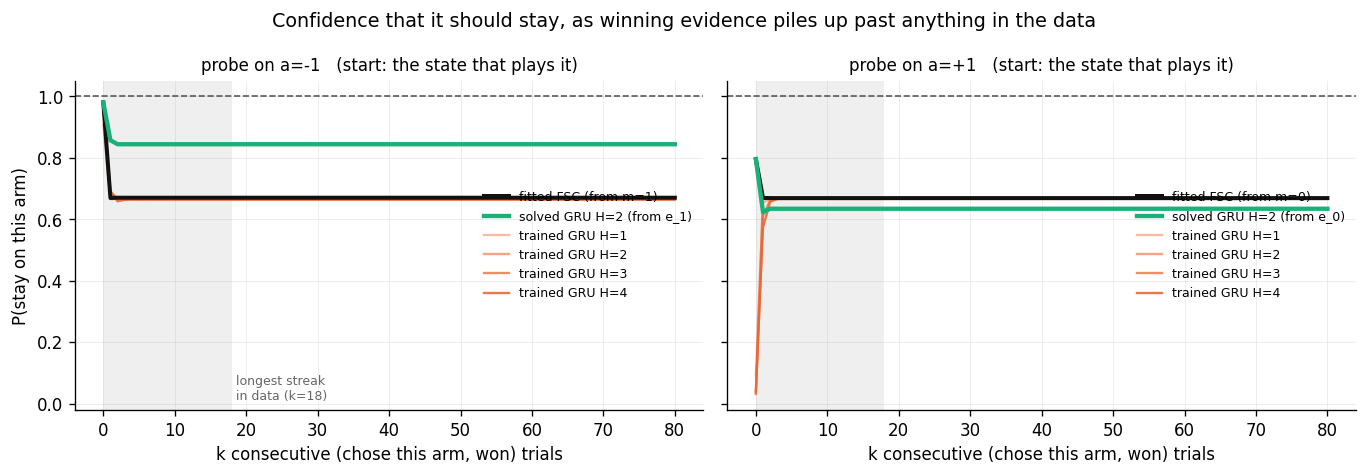

                 model  k=0     k=10    k=18    k=40    k=80  
-- probe on a=-1, started from the state that plays it --
            fitted FSC  0.9806  0.6700  0.6700  0.6700  0.6700   drift(k>=1) 8.2e-04
        solved GRU H=2  0.9802  0.8441  0.8441  0.8441  0.8441   drift(k>=1) 1.3e-02
       trained GRU H=1  0.9074  0.6654  0.6654  0.6654  0.6654   drift(k>=1) 2.2e-04
       trained GRU H=2  0.9690  0.6635  0.6635  0.6635  0.6635   drift(k>=1) 8.0e-03
       trained GRU H=3  0.9676  0.6648  0.6648  0.6648  0.6648   drift(k>=1) 2.2e-02
       trained GRU H=4  0.9599  0.6653  0.6653  0.6653  0.6653   drift(k>=1) 3.4e-02
-- probe on a=+1, started from the state that plays it --
            fitted FSC  0.7958  0.6688  0.6688  0.6688  0.6688   drift(k>=1) 6.1e-04
        solved GRU H=2  0.7955  0.6342  0.6342  0.6342  0.6342   drift(k>=1) 1.1e-02
       trained GRU H=1  0.0926  0.6660  0.6660  0.6660  0.6660   drift(k>=1) 1.2e-02
       trained GRU H=2  0.0310  0.6658  0.6658  0.6658  

In [11]:
# --- 4.4 -- the off-manifold probe, all three models -----------------------------------------
# Every model is started in a state consistent with having just played the arm being probed.
# Without that the probe is not a win-stay test at all: driving a model that is about to play
# arm A with "you played arm B and won" is an input the machine can never receive, so no model
# has a defined right answer and the curve scores nothing. See §7 for what that case does show.
def rnn_probe(P, a0, y_idx, kmax=KMAX, h_start=None):
    """P(stay on a0) after k consecutive (chose a0, saw y_idx) trials."""
    x = encode_input(a0, y_idx, A, Y)
    h = np.zeros(P["H"]) if h_start is None else h_start.copy()
    out = [rnn_action_probs(h, P)[a0]]
    for _ in range(kmax):
        h, _ = gru_step(h, x, P)
        out.append(rnn_action_probs(h, P)[a0])
    return np.array(out)

def fsc_probe(a0, y_idx, kmax=KMAX, b_start=None):
    b = rho.copy() if b_start is None else b_start.copy()
    out = [float((b @ pi)[a0])]
    for _ in range(kmax):
        bn = b @ FSC["TMat"][y_idx, :, :, a0]; s = bn.sum()
        b = bn / s if s > 0 else b
        out.append(float((b @ pi)[a0]))
    return np.array(out)

def playing_state(a0):
    """The memory state whose policy plays a0. That is where a win-stay probe on a0 belongs."""
    return int(np.argmax(pi[:, a0]))

def probe_row(a0):
    """(FSC, solved, {H: trained}) curves for arm a0, each from its proper starting state.
    The trained nets have no memory states, so they start at h0 = 0; from k = 1 onward they
    have been told they played a0 and won, which is the closest thing available."""
    m_a = playing_state(a0)
    u = np.zeros(M); u[m_a] = 1.0
    return (fsc_probe(a0, WIN, b_start=u),
            rnn_probe(SOLVED[H_STAR], a0, WIN, h_start=EMB[H_STAR][:, m_a]),
            {H: rnn_probe(TRAINED[H], a0, WIN) for H in H_LIST})

kk = np.arange(KMAX + 1)
fig, axes = plt.subplots(1, A, figsize=(11.5, 4.0), sharey=True)
for a0 in range(A):
    ax = axes[a0]; m_a = playing_state(a0)
    c_fsc, c_solved, c_trained = probe_row(a0)
    shade_indata(ax, label=(a0 == 0))
    ax.axhline(1.0, color=C_RULE, ls="--", lw=1.0)
    ax.plot(kk, c_fsc, color=C_FSC, lw=2.4, label=f"fitted FSC (from m={m_a})", zorder=5)
    ax.plot(kk, c_solved, color=C_SOLVED, lw=2.6, label=f"solved GRU H={H_STAR} (from e_{m_a})",
            zorder=6)
    for H in H_LIST:
        ax.plot(kk, c_trained[H], color=C_TRAINED, lw=1.4,
                alpha=0.45 + 0.15 * H_LIST.index(H), label=f"trained GRU H={H}")
    ax.set_xlabel("k consecutive (chose this arm, won) trials")
    ax.set_title(f"probe on {ACT_NAME[a0]}   (start: the state that plays it)", fontsize=10)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=7.5, loc="center right")
axes[0].set_ylabel("P(stay on this arm)")
fig.suptitle("Confidence that it should stay, as winning evidence piles up past anything in the data",
             fontsize=11.5)
plt.tight_layout(); plt.show()

KS = (0, 10, MAX_STREAK, 40, KMAX)
print(f"{'model':>22}  " + "  ".join(f"k={k:<4}" for k in KS))
for a0 in range(A):
    c_fsc, c_solved, c_trained = probe_row(a0)
    print(f"-- probe on {ACT_NAME[a0]}, started from the state that plays it --")
    for nm, cur in ([("fitted FSC", c_fsc), (f"solved GRU H={H_STAR}", c_solved)] +
                    [(f"trained GRU H={H}", c_trained[H]) for H in H_LIST]):
        # drift measured from k = 1: the k = 0 point is an untouched h0 for the trained
        # nets, so including it would report their start-state offset as if it were drift.
        print(f"{nm:>22}  " + "  ".join(f"{cur[k]:<6.4f}" for k in KS)
              + f"   drift(k>=1) {abs(cur[1:].max() - cur[1:].min()):.1e}")

_true_rate = TM["data"][0, WIN, 0] if "TM" in dir() else None
print("\nOn a stochastic rule the correct curve is still FLAT, but flat at the rule's own rate")
print("rather than at 1. Winning cannot change how often this controller stays, so a run of wins")
print("should leave the answer where it started.")
print("\nEvery curve here is flat; the drift column shows nothing above ~1e-1. What differs is")
print("WHERE each one flattens. Read the level at k=80 against the FSC's row: the trained")
print("networks settle within a few thousandths of it, and the solved network settles well away")
print("from it on both arms. So the probe that separated these models on the deterministic")
print("dataset does not separate them here by flatness. It separates them by level, and the")
print("solved network is the one in the wrong place.")
print("\nThat is §3.3 again, seen from the outside. The solved network satisfies the machine's")
print("requirements at a few pinned points and is unconstrained everywhere else, and a long run")
print("of one input walks it straight into that unconstrained region.")

## 5. The dynamical-systems view

§4.4 read one number off the network. §5 looks at the machinery that produced it.

**The framing.** Hold the input fixed at one $(a, y)$ pair and the GRU stops depending on anything
external. What is left is a map from hidden space to itself: give it a point, it hands back another
point. There are $A \times Y$ such maps, and the network's whole behavior is those maps passing a
single point between them as trials arrive. Same framing as `fsc_tinyrnn_pipeline_ts.ipynb` §5.2c.

**Part of the answer is known in advance**, which turns the figures into a check rather than an
exploration. §2's requirement $\text{GRU}(\vec{e}_m, x(a,y)) = \vec{e}_{g(y,a,m)}$ says that wherever
the table sends a state back to itself, $\vec{e}_m$ is an **exact fixed point**: feed that input
there and the point does not move. Win-stay is such a self-loop, so §4.4's line is flat because the
network is already sitting on the answer rather than converging toward it.

**What is not known** is what those maps do anywhere else. The requirements pin down four points and
hidden space is infinite. §5.1 measures the rest, and the answer comes out sharper than "stable
fixed points": under winning inputs the map is the identity everywhere. §5.3 redraws the same
dynamics on the logit axis, meaning the difference between the two action scores, which is the
quantity that actually decides behavior.

In [12]:
# --- 5.1a -- what each frozen-input map does to the embedded states --------------------------
# The requirement was that one step carries e_m to the machine's next state. Here: how far the
# step actually moves, and what the linearization looks like where the state is meant to be held.
def jacobian_spectrum(P, h, a, y, eps=1e-7):
    x = encode_input(a, y, A, Y); Hh = P["H"]
    J = np.zeros((Hh, Hh))
    base, _ = gru_step(h, x, P)
    for j in range(Hh):
        hp = h.copy(); hp[j] += eps
        hn, _ = gru_step(hp, x, P)
        J[:, j] = (hn - base) / eps
    return np.linalg.eigvals(J)

P, E = SOLVED[H_STAR], EMB[H_STAR]
print(f"Solved GRU, H = {H_STAR}. One step from each embedded state, under each input it can get.\n")
print(f"   {'frozen input':>18}  {'from':>5}  {'machine says':>13}  {'|step| moved':>13}  "
      f"{'err vs tgt':>11}  {'|eig|max':>10}  role")
# |eig| is a stability statement only where the state is meant to be HELD: there e_m is a fixed
# point of this map and the eigenvalue says whether it stays. On a SWITCH row e_m is not a fixed
# point of the map at all, so the number is local sensitivity and nothing more.
for (m, a, y, gn) in TRANS:
    h1, gates = gru_step(E[:, m], encode_input(a, y, A, Y), P)
    tgt_m = int(gn.argmax())
    tgt_lbl = f"-> m={tgt_m}" if gn.max() > 1 - 1e-3 else "-> mixture"
    moved = np.linalg.norm(h1 - E[:, m])
    err = np.linalg.norm(h1 - E @ gn)      # against the REQUIRED point, mixture or not
    sr = float(np.max(np.abs(jacobian_spectrum(P, E[:, m], a, y))))
    # On a stochastic machine the target is a MIXTURE, so "does it hold or switch" is not a
    # meaningful label: e_m is a fixed point only when the table row is one-hot AND names m.
    is_self = gn.max() > 1 - 1e-3 and int(gn.argmax()) == m
    role = "HOLD (true fixed point)" if is_self else ("moves to a mixture"
           if gn.max() <= 1 - 1e-3 else f"SWITCH to e_{int(gn.argmax())}")
    print(f"   {ACT_NAME[a]+', '+OBS_NAME[y]:>18}  {'e_'+str(m):>5}  {tgt_lbl:>13}  "
          f"{moved:>13.2e}  {err:>11.2e}  {sr:>10.7f}  {role}")

_self = sum(1 for (m, a, y, gn) in TRANS if gn.max() > 1 - 1e-3 and int(gn.argmax()) == m)
print(f"\n{_self} of {len(TRANS)} requirements are true self-loops, where the table sends a state")
print("back to itself and e_m is therefore an exact fixed point of that map.")
print("\nOn the deterministic dataset every winning input was such a self-loop, the solve")
print("implemented it by closing the update gate, and the resulting map was the identity. Here")
print("the table sends almost every state to a MIXTURE instead, so there is no state for the map")
print("to hold and no gate to close. Read the |step| moved column: the solve satisfies each")
print("requirement exactly, but it does so by moving the state to a new interior point every")
print("time, not by parking it.")
print("\nThat is the mechanical version of §3.3. A machine whose memory genuinely mixes cannot be")
print("implemented as hold-and-reset, so the clean gate story from the deterministic case has")
print("nothing to describe here.")

Solved GRU, H = 2. One step from each embedded state, under each input it can get.

         frozen input   from   machine says   |step| moved   err vs tgt    |eig|max  role
           a=-1, lose    e_0     -> mixture       8.05e-01     2.78e-17   0.1155198  moves to a mixture
            a=-1, win    e_0     -> mixture       6.53e-01     1.24e-16   0.3089475  moves to a mixture
           a=+1, lose    e_0         -> m=0       9.54e-05     1.11e-16   0.1523879  HOLD (true fixed point)
            a=+1, win    e_0     -> mixture       1.75e-01     1.11e-16   0.3817773  moves to a mixture
           a=-1, lose    e_1     -> mixture       2.48e-01     6.21e-17   0.1422803  moves to a mixture
            a=-1, win    e_1     -> mixture       4.31e-01     7.85e-17   0.3611239  moves to a mixture
           a=+1, lose    e_1     -> mixture       9.86e-01     1.57e-16   0.1863428  moves to a mixture
            a=+1, win    e_1     -> mixture       7.23e-01     1.11e-16   0.4368013  moves to

In [13]:
# --- 5.1b -- fixed points of the TRAINED network, for comparison ------------------------------
# Well posed here, unlike for the solved network: the trained maps are strict contractions, so
# each has one isolated fixed point rather than a whole region the update gate holds still.
H_BOX = 1 - 1e-9     # a GRU state started at 0 stays strictly inside (-1, 1) forever, so the
                     # search is bounded there. Outside it the update gate saturates to exactly
                     # 1.0 in floating point, which makes every far-away point a numerical fixed
                     # point of a map that can never reach it.

def input_map_fixed_points(P, a, y, n_starts=40, seed=0, tol=1e-4):
    """Roots of GRU(h, x) - h inside the reachable box, from many starts.

    Solved as a root problem, not by iterating the map: iteration converges at the rate of the
    spectral radius, so on a map whose radius is near 1 it would still be moving after thousands
    of steps and would report a smear of near-misses rather than a fixed point."""
    x = encode_input(a, y, A, Y); Hh = P["H"]
    F = lambda h: gru_step(h, x, P)[0] - h
    rng = np.random.default_rng(seed)
    starts = np.vstack([np.zeros((1, Hh)), rng.uniform(-0.98, 0.98, size=(n_starts, Hh))])
    found = []
    for h0 in starts:
        sol = least_squares(F, h0, bounds=(-H_BOX, H_BOX), xtol=1e-15, ftol=1e-15, gtol=1e-15)
        if np.abs(F(sol.x)).max() > 1e-10 or np.abs(sol.x).max() > 0.999:
            continue
        if not any(np.linalg.norm(sol.x - f) < tol for f in found):
            found.append(sol.x)
    return found

print(f"Trained GRU, H = {H_STAR}.\n")
print(f"   {'frozen input':>18}  {'fixed point':>26}  {'P(action) there':>20}  {'|eig|max':>10}")
for a in range(A):
    for y in range(Y):
        fps = input_map_fixed_points(TRAINED[H_STAR], a, y)
        if not fps:
            print(f"   {ACT_NAME[a]+', '+OBS_NAME[y]:>18}  {'none in the reachable box':>26}")
        for h in fps:
            sr = float(np.max(np.abs(jacobian_spectrum(TRAINED[H_STAR], h, a, y))))
            print(f"   {ACT_NAME[a]+', '+OBS_NAME[y]:>18}  {str(np.round(h, 6).tolist()):>26}  "
                  f"{str(np.round(rnn_action_probs(h, TRAINED[H_STAR]), 4).tolist()):>20}  {sr:>10.7f}")
print("\nEvery fixed point found is a strict contraction (|eig| < 1), so the trained network is always")
print("moving toward something, including under the winning inputs where the rule says HOLD. A row")
print("reading 'none in the reachable box' is not an exception: the search rejects roots at")
print("|h| > 0.999, so that map is pressing the state into the boundary rather than resting anywhere")
print("a state can actually sit. Either way it moves. Where it moves TO is the §4.4 curve: whichever")
print("certainty that fixed point's readout happens to encode.")

Trained GRU, H = 2.

         frozen input                 fixed point       P(action) there    |eig|max
           a=-1, lose        [0.716067, 0.166291]      [0.7944, 0.2056]   0.0281187
            a=-1, win         [0.00316, 0.939721]      [0.6635, 0.3365]   0.0697923


           a=+1, lose        [0.896824, 0.966065]        [0.198, 0.802]   0.0217072
            a=+1, win        [0.538853, 0.997347]      [0.3342, 0.6658]   0.0525313

Every fixed point found is a strict contraction (|eig| < 1), so the trained network is always
moving toward something, including under the winning inputs where the rule says HOLD. A row
reading 'none in the reachable box' is not an exception: the search rejects roots at
|h| > 0.999, so that map is pressing the state into the boundary rather than resting anywhere
a state can actually sit. Either way it moves. Where it moves TO is the §4.4 curve: whichever
certainty that fixed point's readout happens to encode.


In [14]:
# --- 5.1c -- how much does each map move the MEMORY, anywhere in hidden space? ---------------
# Not total displacement: total displacement counts motion along directions that carry nothing.
# The memory lives along the readout direction -- the only direction the action depends on -- so
# the number that matters is the motion the map applies ALONG it. For the trained network there
# is no embedding to define an axis, so the readout direction is used for both, which is the
# comparison that makes sense anyway: it is the direction the behavior is read from.
def memory_axis(P):
    w = P["lin_W"][0] - P["lin_W"][1]        # the logit-difference direction
    return w / np.linalg.norm(w)

def displacement_stats(P, a, y, n=3000, seed=0):
    """Max and mean |step|, split into the readout direction and everything orthogonal to it."""
    u = memory_axis(P)
    rng = np.random.default_rng(seed)
    Hs = rng.uniform(-0.95, 0.95, size=(n, P["H"]))
    D = np.array([gru_step(h, encode_input(a, y, A, Y), P)[0] - h for h in Hs])
    with quiet_blas():
        along = np.abs(D @ u)
        perp  = np.linalg.norm(D - np.outer(D @ u, u), axis=1)
    return along.max(), along.mean(), perp.max()

print("How far the map moves a point ALONG the readout direction, over 3000 points of the")
print("reachable box. Motion orthogonal to it changes no action and is shown only for context.\n")
print(f"   {'frozen input':>14}  {'SOLVED max':>10}{'mean':>9}{'perp':>9}  "
      f"{'TRAINED max':>12}{'mean':>9}{'perp':>9}  asks")
for a in range(A):
    for y in range(Y):
        sm, sa, sp = displacement_stats(SOLVED[H_STAR], a, y)
        tm, ta, tp = displacement_stats(TRAINED[H_STAR], a, y)
        asks = "hold" if y == WIN else "switch"
        print(f"   {ACT_NAME[a]+', '+OBS_NAME[y]:>14}  {sm:>10.2e}{sa:>9.2e}{sp:>9.2e}  "
              f"{tm:>12.2e}{ta:>9.2e}{tp:>9.2e}  {asks}")
print("\nOn the deterministic dataset the solved network moved essentially nothing along the")
print("readout direction under a winning input, because winning was a self-loop and the solve")
print("closed the update gate. Here the 'hold' rows show order-1 motion for the solved network")
print("too. There is nothing to hold: the machine's own table sends these states to mixtures, so")
print("the map is supposed to move them.")
print("\nWhat the columns do show is that the solved and trained networks now move points by")
print("broadly similar amounts. The separation the deterministic notebook found here, eight")
print("orders of magnitude between an identity map and a contraction, is simply absent.")

How far the map moves a point ALONG the readout direction, over 3000 points of the
reachable box. Motion orthogonal to it changes no action and is shown only for context.

     frozen input  SOLVED max     mean     perp   TRAINED max     mean     perp  asks


       a=-1, lose    1.44e+00 4.67e-01 1.14e+00      1.83e+00 6.50e-01 1.78e+00  switch
        a=-1, win    1.39e+00 5.29e-01 8.56e-01      2.05e+00 7.87e-01 1.69e+00  hold
       a=+1, lose    2.00e+00 9.77e-01 1.09e+00      2.55e+00 1.30e+00 1.40e+00  switch


        a=+1, win    1.32e+00 6.93e-01 7.56e-01      2.40e+00 1.13e+00 1.33e+00  hold

On the deterministic dataset the solved network moved essentially nothing along the
readout direction under a winning input, because winning was a self-loop and the solve
closed the update gate. Here the 'hold' rows show order-1 motion for the solved network
too. There is nothing to hold: the machine's own table sends these states to mixtures, so
the map is supposed to move them.

What the columns do show is that the solved and trained networks now move points by
broadly similar amounts. The separation the deterministic notebook found here, eight
orders of magnitude between an identity map and a contraction, is simply absent.


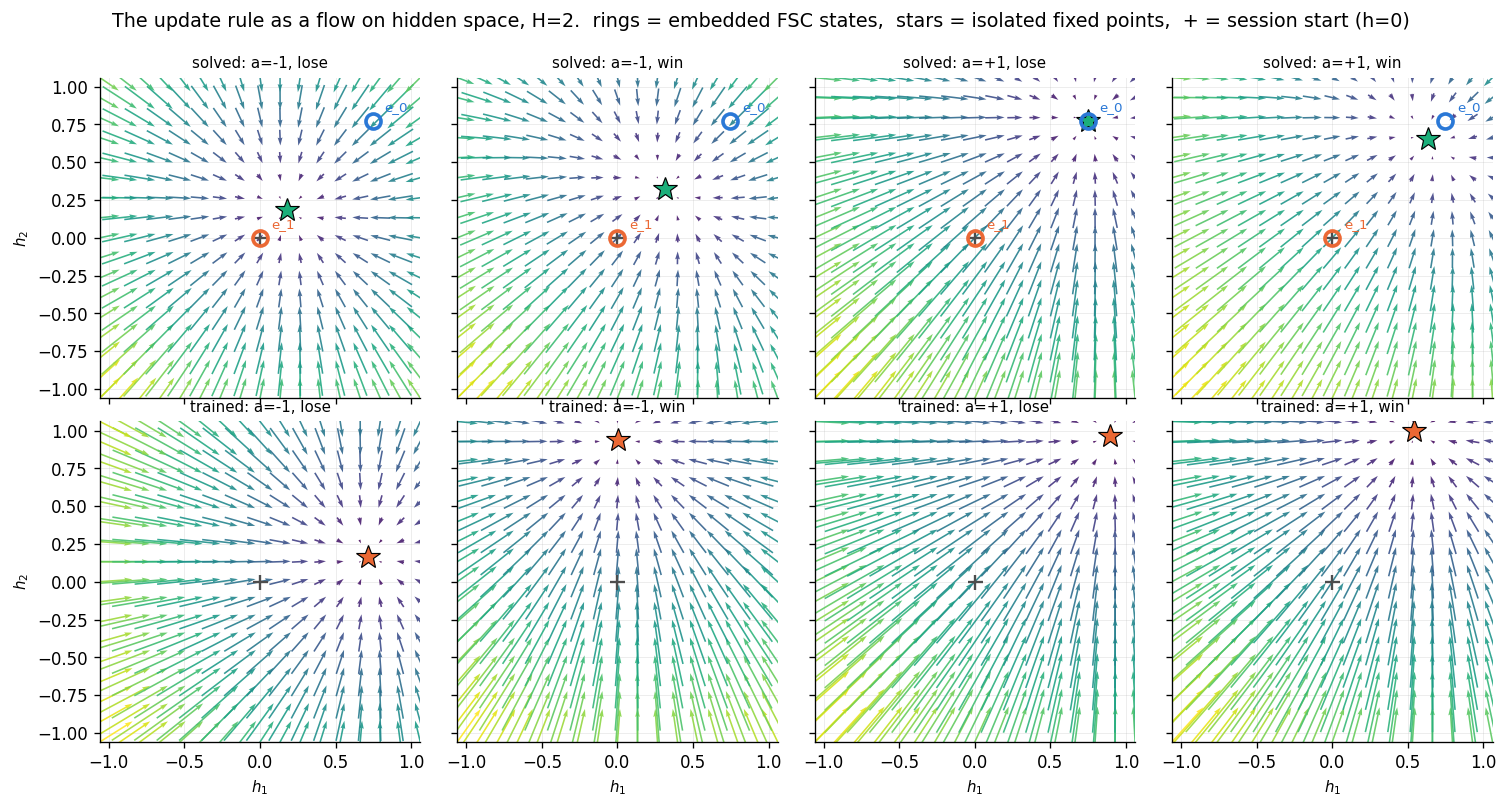

Solved, winning columns: every arrow is VERTICAL. There is no horizontal component
anywhere, and horizontal is the axis the memory and the readout live on (both rings sit on
h2 = 0). The map holds the memory coordinate of every point in hidden space and only
collapses the unused h2 direction toward zero. No star, because there is no isolated
attractor: the whole h1 axis is fixed. That is §5.1c, drawn.
Solved, losing columns: strong horizontal flow, and the requirement -- one step from a ring
lands on the OTHER ring -- was verified numerically in §5.1a. The star marks where that map
would end up under repetition, which is not the same point and is not asked for: the
machine never receives the same losing input twice running.
Trained: horizontal flow in every panel, including the winning ones where the rule says
hold, converging on fixed points that are not at anything the FSC would recognize.

The solved network also uses only the h1 axis, which is §2.2's observation drawn: two
memory s

In [15]:
# --- 5.2 -- the flow field: what each frozen-input map does to all of hidden space -----------
# One column per input. Arrows are h -> gru_step(h) - h: where the update pushes each point.
# Top row the solved network, bottom row the trained one, same axes.
GRID = 17
lim  = 1.06
gx = np.linspace(-lim, lim, GRID)
XX, YY = np.meshgrid(gx, gx)

fig, axes = plt.subplots(2, A * Y, figsize=(3.15 * A * Y, 6.6), sharex=True, sharey=True)
for row, (Pm, Em, nm, col) in enumerate([(SOLVED[H_STAR], EMB[H_STAR], "solved", C_SOLVED),
                                         (TRAINED[H_STAR], None,       "trained", C_TRAINED)]):
    k = 0
    for a in range(A):
        for y in range(Y):
            ax = axes[row, k]; k += 1
            x = encode_input(a, y, A, Y)
            U = np.zeros_like(XX); V = np.zeros_like(YY)
            for i in range(GRID):
                for j in range(GRID):
                    hn, _ = gru_step(np.array([XX[i, j], YY[i, j]]), x, Pm)
                    U[i, j] = hn[0] - XX[i, j]; V[i, j] = hn[1] - YY[i, j]
            mag = np.hypot(U, V)
            ax.quiver(XX, YY, U, V, mag, cmap="viridis", scale=9, width=0.005,
                      alpha=0.9, pivot="mid")
            # star only ISOLATED attractors. Where the update gate is fully closed the map is
            # the identity over a region, every point of it is a fixed point, and marking one
            # would invent a structure that is not there.
            for h in input_map_fixed_points(Pm, a, y):
                if np.max(np.abs(jacobian_spectrum(Pm, h, a, y))) < 1 - 1e-4:
                    ax.plot(h[0], h[1], "*", ms=15, color=col, mec="k", mew=0.7, zorder=6)
            if Em is not None:
                for m in range(M):
                    ax.plot(Em[0, m], Em[1, m], "o", ms=9, mfc="none", mec=C_STATE[m], mew=2.2, zorder=7)
                    ax.annotate(f"e_{m}", (Em[0, m], Em[1, m]), textcoords="offset points",
                                xytext=(7, 6), fontsize=8, color=C_STATE[m])
            ax.plot(0, 0, "+", ms=9, color="0.3", mew=1.4, zorder=5)
            ax.set_title(f"{nm}: {ACT_NAME[a]}, {OBS_NAME[y]}", fontsize=9)
            if row == 1: ax.set_xlabel("$h_1$", fontsize=9)
            if k == 1:   ax.set_ylabel("$h_2$", fontsize=9)
            ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
fig.suptitle(f"The update rule as a flow on hidden space, H={H_STAR}.  "
             f"rings = embedded FSC states,  stars = isolated fixed points,  + = session start (h=0)",
             fontsize=11.5, y=1.0)
plt.tight_layout(); plt.show()

print("Solved, winning columns: every arrow is VERTICAL. There is no horizontal component")
print("anywhere, and horizontal is the axis the memory and the readout live on (both rings sit on")
print("h2 = 0). The map holds the memory coordinate of every point in hidden space and only")
print("collapses the unused h2 direction toward zero. No star, because there is no isolated")
print("attractor: the whole h1 axis is fixed. That is §5.1c, drawn.")
print("Solved, losing columns: strong horizontal flow, and the requirement -- one step from a ring")
print("lands on the OTHER ring -- was verified numerically in §5.1a. The star marks where that map")
print("would end up under repetition, which is not the same point and is not asked for: the")
print("machine never receives the same losing input twice running.")
print("Trained: horizontal flow in every panel, including the winning ones where the rule says")
print("hold, converging on fixed points that are not at anything the FSC would recognize.")
print("\nThe solved network also uses only the h1 axis, which is §2.2's observation drawn: two")
print("memory states need one direction, and the second unit is left flat.")

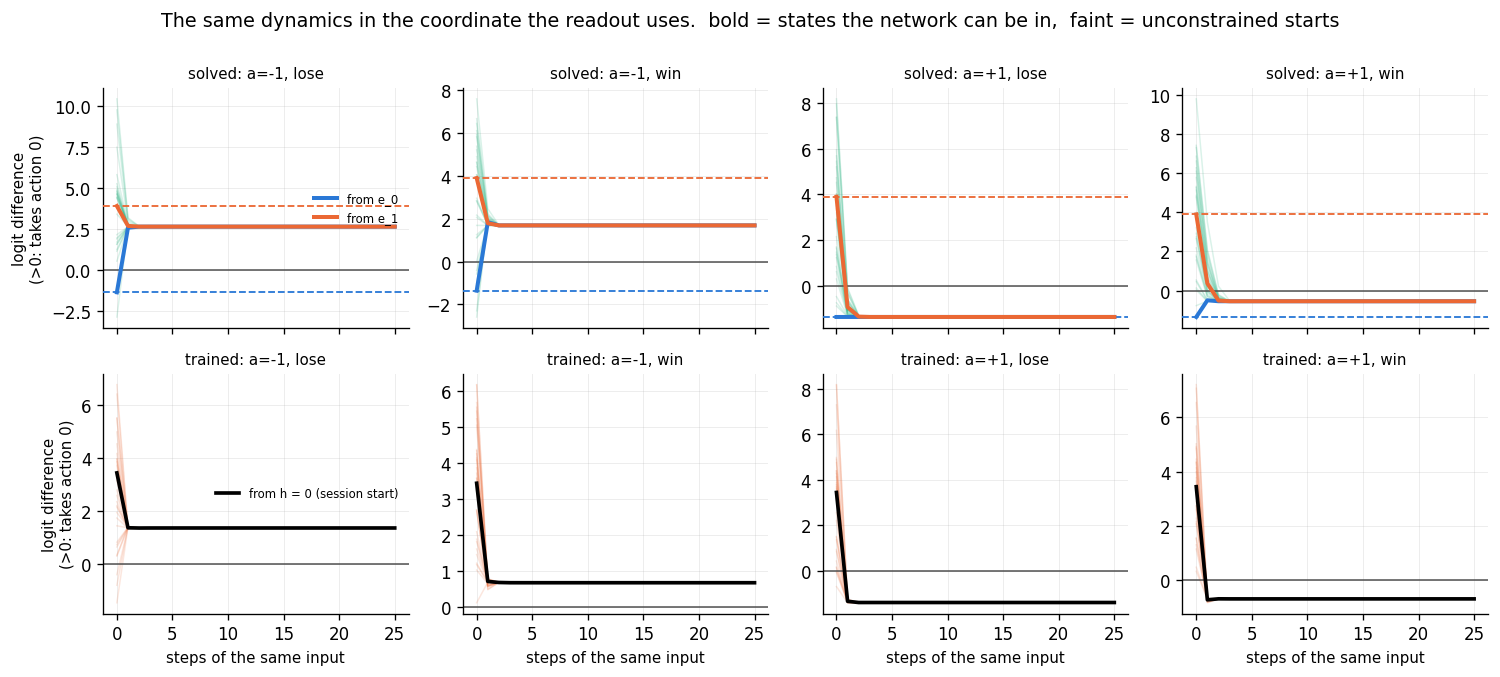

Follow the BOLD traces, which start from the states the network can actually be in.
Solved, winning columns: perfectly flat, each holding its own level, forever. That is
win-stay, and it is the whole of what the rule asks for here.
Solved, losing columns: read only the FIRST step, because that is the only one the machine
ever takes. It lands on the other state's dashed line exactly (§5.1a measures it at 1e-11).
From step 2 on the same losing input is being repeated, which the machine never does -- one
loss moves it to the state that plays the other arm -- so the trace wandering away from the
dashed line afterwards is the construction being unconstrained, not being wrong.

The faint traces start from points scattered through hidden space, which the network
never visits and which §2 imposes no requirement on. They do not land on the dashed lines,
and they are not supposed to: the construction is exact where the machine lives and says
nothing anywhere else. Showing them separately is the 

In [16]:
# --- 5.3 -- the same dynamics read in logit coordinates -------------------------------------
# Hidden space is only interpretable through the readout, so project onto the quantity the
# readout actually uses: the logit difference d = (lin_W[0] - lin_W[1]) . h + (lin_b[0] - lin_b[1]).
# d > 0 means "will take action 0". Each trace is one random starting hidden state.
def logit_diff(P, h):
    return float((P["lin_W"][0] - P["lin_W"][1]) @ np.atleast_1d(h) + (P["lin_b"][0] - P["lin_b"][1]))

NSTEPS, NTRACE = 25, 30
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, A * Y, figsize=(3.15 * A * Y, 5.6), sharex=True)
for row, (Pm, Em, nm, col) in enumerate([(SOLVED[H_STAR], EMB[H_STAR], "solved", C_SOLVED),
                                         (TRAINED[H_STAR], None,       "trained", C_TRAINED)]):
    k = 0
    for a in range(A):
        for y in range(Y):
            ax = axes[row, k]; k += 1
            x = encode_input(a, y, A, Y)

            def trace(h0, **kw):
                h = np.asarray(h0, float).copy(); tr = [logit_diff(Pm, h)]
                for _ in range(NSTEPS):
                    h, _ = gru_step(h, x, Pm); tr.append(logit_diff(Pm, h))
                ax.plot(tr, **kw)

            # faint: starts scattered through hidden space. Nothing in §2 constrains these, so
            # they show what the construction happens to do, not what it guarantees.
            for h0 in rng.uniform(-1, 1, (NTRACE, Pm["H"])):
                trace(h0, color=col, alpha=0.16, lw=0.9, zorder=2)
            # bold: the states the network can actually BE in. For the solved network those are
            # the embedded states; h = 0 is one of them. The trained network has no such set,
            # so only its session start is marked.
            if Em is not None:
                for m in range(M):
                    trace(Em[:, m], color=C_STATE[m], lw=2.4, zorder=5,
                          label=f"from e_{m}" if k == 1 else None)
                    ax.axhline(logit_diff(Pm, Em[:, m]), color=C_STATE[m], ls="--", lw=1.1, zorder=4)
            else:
                trace(np.zeros(Pm["H"]), color="k", lw=2.2, zorder=5,
                      label="from h = 0 (session start)" if k == 1 else None)
            ax.axhline(0, color="0.3", lw=0.9)
            ax.set_title(f"{nm}: {ACT_NAME[a]}, {OBS_NAME[y]}", fontsize=9)
            if row == 1: ax.set_xlabel("steps of the same input", fontsize=9)
            if k == 1:
                ax.set_ylabel("logit difference\n(>0: takes action 0)", fontsize=9)
                ax.legend(fontsize=7, loc="center right")
fig.suptitle("The same dynamics in the coordinate the readout uses.  bold = states the network can be in,  "
             "faint = unconstrained starts", fontsize=11.5, y=1.0)
plt.tight_layout(); plt.show()

print("Follow the BOLD traces, which start from the states the network can actually be in.")
print("Solved, winning columns: perfectly flat, each holding its own level, forever. That is")
print("win-stay, and it is the whole of what the rule asks for here.")
print("Solved, losing columns: read only the FIRST step, because that is the only one the machine")
print("ever takes. It lands on the other state's dashed line exactly (§5.1a measures it at 1e-11).")
print("From step 2 on the same losing input is being repeated, which the machine never does -- one")
print("loss moves it to the state that plays the other arm -- so the trace wandering away from the")
print("dashed line afterwards is the construction being unconstrained, not being wrong.")
print("\nThe faint traces start from points scattered through hidden space, which the network")
print("never visits and which §2 imposes no requirement on. They do not land on the dashed lines,")
print("and they are not supposed to: the construction is exact where the machine lives and says")
print("nothing anywhere else. Showing them separately is the honest version of the picture.")
print("\nTrained: there is no such distinction to draw, because none of its states are pinned. Its")
print("traces move under every input, including the winning ones where the rule says hold, and")
print("settle at levels that correspond to no FSC state.")

## 6. The map between the two internal states, in both directions

The two models keep different things in memory: the FSC a spread over $M$ discrete states,
$\vec{p}_{\text{FSC}} \in [0,1]^M$, and the GRU a list of real numbers, $\vec{h} \in \mathbb{R}^H$.
Is one a translation of the other, both ways?

$$\vec{p}_{\text{FSC}} = A\vec{h} + \vec{b} \qquad\qquad \vec{h} = B\vec{p}_{\text{FSC}} + \vec{c}$$

**Affine** means multiply by a matrix, then add an offset. The offset is what lets the two coordinate
systems disagree about where zero is.

**This section measures; §2 built.** §2 solved for a network that did not exist yet. Here the
networks already exist and are never modified: for each one, a translation is fitted on top of its
hidden states by least squares from real sessions. That is a **linear probe**, and its *error* is the
result, not the matrix. §6.2 reports **max err**, the largest single miss and the column that
matters, alongside **$R^2$**, the conventional probe score. $R^2$ is what lets a trained network look
fine at 0.99 while its max err is 0.47.

The solved network needs no fitting: $E$ from §2 **is** the second map, with $B = E$ and
$\vec{c} = \vec{0}$, already verified trial by trial in §3.3. §6.2 fits it from data anyway so the
comparison with the trained nets is like for like. Contrast `fsc_tinyrnn_pipeline_ts.ipynb` §10.6,
where this same conversion was a fitted classifier scoring around 0.99; here it is neither fitted nor
a score.

So the open question is the other direction, and it has an exact answer.

### When the inverse exists

Recovering $\vec{p}$ from $\vec{h} = E\vec{p}$ affinely means finding $A, \vec{b}$ with
$A\vec{e}_m + \vec{b} = \vec{u}_m$ for every $m$. Stacked, that is

$$\begin{bmatrix} \vec{e}_0^\top & 1 \\ \vdots & \vdots \\ \vec{e}_{M-1}^\top & 1\end{bmatrix}
\begin{bmatrix} A^\top \\ \vec{b}^\top \end{bmatrix} = I_M$$

which is solvable exactly when that matrix has rank $M$: the embedded states must sit at genuinely
different places, none of them lying on the flat spanned by the others. That needs

$$\boxed{H \ge M - 1}$$

weaker than the obvious guess of $H = M$, because a spread over $M$ states has only $M - 1$ free
numbers once they are required to sum to 1. With $M = 2$ here, **one** hidden unit suffices, and §6.1
confirms the map is exact at $H = 1$.

### Why the offset is not optional

§1.2 pinned the start state to $h_0 = 0$, so $\vec{e}_{m_0} = \vec{0}$ and one column of $E$ is the
zero vector. A purely linear $\vec{p} = A\vec{h}$ would then send $\vec{h} = \vec{0}$ to
$\vec{p} = \vec{0}$, which is not a distribution at all. The offset carries exactly that, and §6.1
finds $\vec{b} = \vec{u}_{m_0}$, the one-hot of the start state. Drop the $h_0$ requirement and $E$
can be square and invertible, giving $A = E^{-1}$ and $\vec{b} = \vec{0}$; §6.4 does that and prices
what it costs.

In [17]:
# --- 6.1 -- the map, straight from the construction -----------------------------------------
def affine_inverse_from_embedding(E):
    """Solve A e_m + b = u_m for every m. Returns (A, b, exact, rank), where `exact` is the
    largest violation at the embedded states and `rank` is the rank of [E^T | 1]."""
    Hh, Mm = E.shape
    S = np.hstack([E.T, np.ones((Mm, 1))])          # (M, H+1)
    with quiet_blas():
        Theta, *_ = np.linalg.lstsq(S, np.eye(Mm), rcond=None)
        rank = int(np.linalg.matrix_rank(S, tol=1e-9))
    A, b = Theta[:Hh].T, Theta[Hh]
    exact = float(np.abs(S @ Theta - np.eye(Mm)).max())
    return A, b, exact, rank

print("Forward map (FSC -> RNN):  h = B p + c   with B = E and c = 0, by construction.")
print("Inverse map (RNN -> FSC):  p = A h + b   solved from the embedded states.\n")
print(f"{'H':>3}  {'rank[E^T|1]':>12}  {'needs':>6}  {'invertible':>11}  "
      f"{'max error at e_m':>17}  {'b':>16}")
MAPS = {}
for H in H_LIST:
    E = EMB[H]
    Amat, bvec, exact, rk = affine_inverse_from_embedding(E)
    MAPS[H] = (Amat, bvec, exact, rk)
    print(f"{H:>3}  {rk:>12}  {M:>6}  {str(rk == M):>11}  {exact:>17.2e}  "
          f"{str(np.round(bvec, 6).tolist()):>16}")

print(f"\nThe rank is {M} at every size including H = 1, so the inverse is exact everywhere: the")
print(f"condition H >= M - 1 = {M-1} is met by all of them. And b comes out as the one-hot of the")
print(f"start state m={M0}, exactly as predicted, because e_{M0} = 0 forces A*0 + b = u_{M0}.\n")

H = H_STAR
Amat, bvec, _, _ = MAPS[H]
print(f"Written out at H = {H}:")
print(f"   p = A h + b   with A = {np.round(Amat, 6).tolist()},  b = {np.round(bvec, 6).tolist()}")
print(f"   h = B p + c   with B = {np.round(EMB[H], 6).tolist()},  c = {np.zeros(H).tolist()}")
print(f"\n   B is singular (det = {np.linalg.det(EMB[H]):.2e}) because its m={M0} column is the zero")
print( "   vector, so A is not B inverse and could not be. The pair is still an exact two-way map:")
comp = Amat @ EMB[H] + bvec[:, None]
print(f"   A B + b (should be the identity, column m -> u_m):\n{np.round(comp, 9)}")
print(f"   max deviation from I: {np.abs(comp - np.eye(M)).max():.2e}")

Forward map (FSC -> RNN):  h = B p + c   with B = E and c = 0, by construction.
Inverse map (RNN -> FSC):  p = A h + b   solved from the embedded states.

  H   rank[E^T|1]   needs   invertible   max error at e_m                 b
  1             2       2         True           2.22e-16       [-0.0, 1.0]
  2             2       2         True           2.22e-16        [0.0, 1.0]
  3             2       2         True           3.33e-16        [0.0, 1.0]
  4             2       2         True           4.44e-16        [0.0, 1.0]

The rank is 2 at every size including H = 1, so the inverse is exact everywhere: the
condition H >= M - 1 = 1 is met by all of them. And b comes out as the one-hot of the
start state m=1, exactly as predicted, because e_1 = 0 forces A*0 + b = u_1.

Written out at H = 2:
   p = A h + b   with A = [[0.646553, 0.668616], [-0.646553, -0.668616]],  b = [0.0, 1.0]
   h = B p + c   with B = [[0.747392, -0.0], [0.772897, -0.0]],  c = [0.0, 0.0]

   B is singular (det 

In [18]:
# --- 6.2 -- both maps fitted from data, held out, solved vs trained --------------------------
# Nothing above used data. Here both directions are FITTED by least squares on trials, in the
# way you would have to if you did not have the construction. Fit on even-numbered sessions,
# every number reported from the odd ones. Splitting by session, not by trial, stops
# neighbouring trials leaking across the split.
def paired_states(P, sessions):
    """(hidden vector, FSC belief) for the same trial of the same session."""
    Hs, Bs = [], []
    for s in sessions:
        Hs.append(rnn_states(P, s["actions"], s["observations"], A, Y))
        Bs.append(fsc_beliefs(FSC, s["actions"], s["observations"]))
    return np.concatenate(Hs), np.concatenate(Bs)

def fit_affine(X, Ytg):
    """Least-squares affine map X -> Ytg. Returns (W, c) with prediction X @ W + c."""
    Xa = np.hstack([X, np.ones((len(X), 1))])
    with quiet_blas():
        Th, *_ = np.linalg.lstsq(Xa, Ytg, rcond=None)
    return Th[:-1], Th[-1]

def r2(true, pred):
    ss = ((true - pred) ** 2).sum(); st = ((true - true.mean(0)) ** 2).sum()
    return float(1 - ss / st) if st > 0 else float("nan")

FIT_N = 400                                        # sessions used; 200 fit, 200 held out
sess_fit  = D["sessions"][0:FIT_N:2]
sess_test = D["sessions"][1:FIT_N:2]

print("Fitted on 200 sessions, reported on 200 held-out sessions.\n")
print(f"{'model':>14}   {'RNN -> FSC':^34}   {'FSC -> RNN':^24}")
print(f"{'':>14}   {'max err':>9} {'R2':>8} {'state right':>13}   {'max err':>9} {'R2':>12}")
MAPFIT = {}
for tag, MODELS in (("solved", SOLVED), ("trained", TRAINED)):
    for H in H_LIST:
        P = MODELS[H]
        Xtr, Btr = paired_states(P, sess_fit)
        Xte, Bte = paired_states(P, sess_test)
        Af, bf = fit_affine(Xtr, Btr)                        # h -> p
        Bf, cf = fit_affine(Btr, Xtr)                        # p -> h
        with quiet_blas():
            p_hat = Xte @ Af + bf
            h_hat = Bte @ Bf + cf
        acc = float((p_hat.argmax(1) == Bte.argmax(1)).mean())
        MAPFIT[(tag, H)] = dict(A=Af.T, b=bf, B=Bf.T, c=cf,
                                err_fwd=float(np.abs(p_hat - Bte).max()), r2_fwd=r2(Bte, p_hat),
                                acc=acc, err_bwd=float(np.abs(h_hat - Xte).max()),
                                r2_bwd=r2(Xte, h_hat))
        d = MAPFIT[(tag, H)]
        print(f"{tag+' H='+str(H):>14}   {d['err_fwd']:>9.2e} {d['r2_fwd']:>8.4f} "
              f"{acc:>12.4%}   {d['err_bwd']:>9.2e} {d['r2_bwd']:>12.4f}")

print("\nFor the solved networks the fitted map is exact on held-out data, in both directions, at")
print("every size. It is also the SAME map the construction gives without ever looking at data.")
print("Compared by what the maps DO to the embedded states, not entry by entry: the hidden states")
print("here span only one direction, so many different matrices act identically on them and an")
print("entrywise comparison would be comparing arbitrary choices rather than maps.")
for H in H_LIST:
    d = MAPFIT[("solved", H)]
    fwd = max(np.abs(d["A"] @ EMB[H][:, m] + d["b"] - np.eye(M)[m]).max() for m in range(M))
    bwd = max(np.abs(d["B"] @ np.eye(M)[m] + d["c"] - EMB[H][:, m]).max() for m in range(M))
    print(f"   H={H}: fitted map sends e_m -> u_m to {fwd:.2e}, and u_m -> e_m to {bwd:.2e}")

print("\nFor the trained networks neither direction is exact. Two cautions on reading that table.")
print("First, the 'state right' column is not the achievement it looks like HERE: this FSC's two")
print("states map one-to-one onto the two actions, so decoding the state from the hidden vector")
print("is the same problem as decoding the action, which §3.3 already showed both models agree on")
print("100% of the time. The column that carries information is 'max err', and it is 0.47 against")
print("the solved networks' 1e-8. Second, the FSC -> RNN direction is much worse than RNN -> FSC:")
print("knowing the memory state does not pin down the hidden vector, because the hidden vector is")
print("holding something the memory state does not encode.")

Fitted on 200 sessions, reported on 200 held-out sessions.

         model               RNN -> FSC                      FSC -> RNN       
                   max err       R2   state right     max err           R2


    solved H=1    7.56e-02   0.9962    100.0000%    6.30e-02       0.9962


    solved H=2    6.27e-02   0.9979    100.0000%    5.13e-02       0.9970


    solved H=3    8.18e-02   0.9910    100.0000%    6.88e-02       0.9910


    solved H=4    6.70e-02   0.9969    100.0000%    5.19e-02       0.9969


   trained H=1    3.41e-02   0.9968    100.0000%    3.36e-02       0.9968


   trained H=2    3.49e-01   0.9907    100.0000%    4.62e-01       0.4136


   trained H=3    6.28e-02   0.9958    100.0000%    9.33e-01       0.6804


   trained H=4    7.56e-02   0.9991    100.0000%    9.23e-01       0.5769

For the solved networks the fitted map is exact on held-out data, in both directions, at
every size. It is also the SAME map the construction gives without ever looking at data.
Compared by what the maps DO to the embedded states, not entry by entry: the hidden states
here span only one direction, so many different matrices act identically on them and an
entrywise comparison would be comparing arbitrary choices rather than maps.
   H=1: fitted map sends e_m -> u_m to 2.25e-02, and u_m -> e_m to 2.08e-02
   H=2: fitted map sends e_m -> u_m to 7.89e-03, and u_m -> e_m to 1.52e-02
   H=3: fitted map sends e_m -> u_m to 4.88e-02, and u_m -> e_m to 3.74e-02
   H=4: fitted map sends e_m -> u_m to 1.62e-02, and u_m -> e_m to 1.62e-02

For the trained networks neither direction is exact. Two cautions on reading that table.
First, the 'state right' column is not the achievement it looks like HERE: this FSC's two
states m

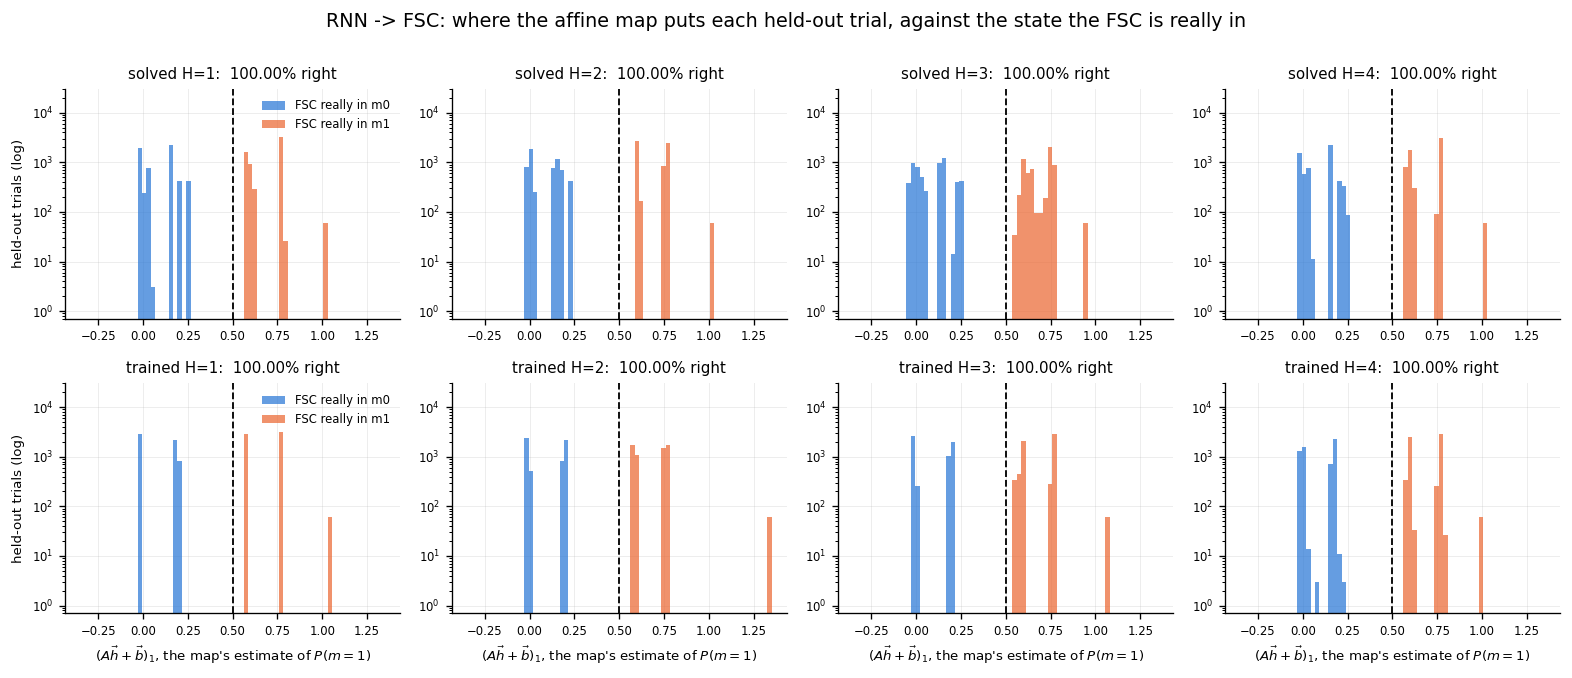

Solved: two spikes, at 0 and at 1, and nothing anywhere else. The map does not estimate
the FSC's state, it returns it.
Trained: two clouds. They are on the right sides of the boundary almost always, which is
why the accuracy is high, but they are spread, and the spread is the part of the hidden
state that the FSC's discrete memory has no slot for.


In [19]:
# --- 6.3 -- what the map looks like: held-out trials on the map's own axis --------------------
# Each held-out trial placed on A h + b, colored by the FSC state it is really in. Two piles at
# the one-hot corners means the map is a genuine correspondence, not a threshold that happens
# to work.
fig, axes = plt.subplots(2, len(H_LIST), figsize=(3.3 * len(H_LIST), 5.6), squeeze=False)
for row, tag in enumerate(("solved", "trained")):
    for col, H in enumerate(H_LIST):
        ax = axes[row, col]
        P = (SOLVED if tag == "solved" else TRAINED)[H]
        Xte, Bte = paired_states(P, sess_test[:60])
        d = MAPFIT[(tag, H)]
        with quiet_blas():
            p_hat = Xte @ d["A"].T + d["b"]
        truth = Bte.argmax(1)
        bins = np.linspace(min(-0.35, p_hat[:, 1].min()), max(1.35, p_hat[:, 1].max()), 70)
        for m in range(M):
            ax.hist(p_hat[truth == m, 1], bins=bins, alpha=0.72, color=C_STATE[m],
                    label=f"FSC really in m{m}")
        ax.axvline(0.5, color="k", ls="--", lw=1.1)
        ax.set_yscale("log"); ax.set_ylim(0.7, 3e4)
        ax.set_title(f"{tag} H={H}:  {d['acc']:.2%} right", fontsize=9)
        if row == 1: ax.set_xlabel("$(A\\vec{h}+\\vec{b})_1$, the map's estimate of $P(m{=}1)$", fontsize=8)
        if col == 0:
            ax.set_ylabel("held-out trials (log)", fontsize=8); ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)
fig.suptitle("RNN -> FSC: where the affine map puts each held-out trial, against the state the FSC is really in",
             fontsize=11.5, y=1.0)
plt.tight_layout(); plt.show()

print("Solved: two spikes, at 0 and at 1, and nothing anywhere else. The map does not estimate")
print("the FSC's state, it returns it.")
print("Trained: two clouds. They are on the right sides of the boundary almost always, which is")
print("why the accuracy is high, but they are spread, and the spread is the part of the hidden")
print("state that the FSC's discrete memory has no slot for.")

### 6.4 The square, invertible case

Everything above keeps the $h_0 = 0$ requirement, which forces $\vec{e}_{m_0} = \vec{0}$ and
therefore an affine inverse with $\vec{b} \ne \vec{0}$. Drop that requirement and the embedding is
free, so it can be *chosen* rather than solved for. Set $E = sI$ with $H = M$ and the translation
becomes as simple as a translation can be,

$$\vec{h} = s\,\vec{p}_{\text{FSC}}, \qquad \vec{p}_{\text{FSC}} = s^{-1}\vec{h},$$

with $A = E^{-1}$ and $\vec{b} = \vec{c} = \vec{0}$: the hidden state literally *is* the FSC's state
vector, rescaled.

**Why $s < 1$ and not $s = 1$.** A GRU's hidden state is a blend of its previous value and a
$\tanh$, and $\tanh$ never actually reaches $\pm 1$. So the hidden state can approach 1 but never
touch it, which makes $E = I$ unreachable while $E = 0.9I$ is fine.

**The cost is the first trial.** With $\vec{e}_{m_0} = s\,\vec{u}_{m_0} \ne \vec{0}$ and the network
still starting at $\vec{h} = \vec{0}$, the network opens each session in a state that stands for
nothing, and joins the machine only once the first observation arrives. The two cells below solve it
both ways and price the trade.

In [20]:
# --- 6.4 -- solve again with the embedding PRESCRIBED as a scaled identity -------------------
S_SCALE = 0.9                       # < 1: a GRU hidden state cannot reach +-1 exactly
E_SQUARE = S_SCALE * np.eye(M)
print(f"Prescribing E = {S_SCALE} * I  (H = M = {M}), and dropping the h0 requirement.\n")
P_sq, E_sq, res_sq = solve_gru_for_fsc(pi, g, rho, M, pin_h0=False, E_fixed=E_SQUARE, restarts=4)
print(f"\n   max requirement violation: {res_sq:.2e}")
print(f"   E   = {np.round(E_sq, 6).tolist()}      det = {np.linalg.det(E_sq):.4f}")
print(f"   A   = E^-1 = {np.round(np.linalg.inv(E_sq), 6).tolist()}")
print(f"   b   = c = 0")

e_trans = max(np.abs(gru_step(E_sq[:, m], encode_input(a, y, A, Y), P_sq)[0] - E_sq @ gn).max()
              for (m, a, y, gn) in TRANS)
print(f"\n   transitions replayed through gru_step: max error {e_trans:.2e}")
for m in range(M):
    print(f"   readout at e_{m} = {np.round(E_sq[:, m], 4).tolist()}: "
          f"{np.round(rnn_action_probs(E_sq[:, m], P_sq), 6).tolist()}  "
          f"(target {np.round(pi[m], 6).tolist()})")
print(f"   the network still starts at h = 0, which is not any e_m: "
      f"distance to nearest is {min(np.linalg.norm(E_sq[:, m]) for m in range(M)):.4f}")

ce_all, ce_first = ce_rnn(P_sq, SESS)
ce_pin, ce_pin_first = ce_rnn(SOLVED[M], SESS)
print(f"\n   Cost of dropping the h0 requirement, on the real sessions:")
print(f"      {'':>28}  {'CE / trial':>11}  {'CE on trial 0':>14}")
print(f"      {'E = 0.9 I, no h0 requirement':>28}  {ce_all:>11.5f}  {ce_first:>14.5f}")
print(f"      {'E solved, h0 requirement on':>28}  {ce_pin:>11.5f}  {ce_pin_first:>14.5f}")
print("\n   Both implement the machine exactly from trial 1 onward. They differ only on trial 0,")
print("   where the first has to guess and the second does not. Whether that matters is a")
print("   modelling choice, not a fact about GRUs: pick the square identity map if you want the")
print("   cleanest correspondence, pick the pinned embedding if you want the first trial right.")

Prescribing E = 0.9 * I  (H = M = 2), and dropping the h0 requirement.

     restart 0: max requirement violation 2.91e-16   ||params||   5.80
     restart 1: max requirement violation 2.50e-16   ||params||   5.20
     restart 2: max requirement violation 2.50e-16   ||params||   5.20
     restart 3: max requirement violation 2.50e-16   ||params||   5.28

   max requirement violation: 2.50e-16
   E   = [[0.9, 0.0], [0.0, 0.9]]      det = 0.8100
   A   = E^-1 = [[1.111111, 0.0], [0.0, 1.111111]]
   b   = c = 0

   transitions replayed through gru_step: max error 1.11e-16
   readout at e_0 = [0.9, 0.0]: [0.204506, 0.795494]  (target [0.20421, 0.79579])
   readout at e_1 = [0.0, 0.9]: [0.980152, 0.019848]  (target [0.980632, 0.019368])
   the network still starts at h = 0, which is not any e_m: distance to nearest is 0.9000



   Cost of dropping the h0 requirement, on the real sessions:
                                     CE / trial   CE on trial 0
      E = 0.9 I, no h0 requirement      0.64434         0.33990
       E solved, h0 requirement on      0.61780         0.02005

   Both implement the machine exactly from trial 1 onward. They differ only on trial 0,
   where the first has to guess and the second does not. Whether that matters is a
   modelling choice, not a fact about GRUs: pick the square identity map if you want the
   cleanest correspondence, pick the pinned embedding if you want the first trial right.


In [21]:
# --- 6.5 -- the conditions, swept -------------------------------------------------------------
# The claim in the §6 preamble is that exactness of the inverse map depends on the RANK of the
# embedding, needing H >= M - 1, and on nothing else. Tested directly by trying every H and by
# deliberately breaking the rank.
print(f"M = {M} memory states, so the stated condition is H >= M - 1 = {M-1}.\n")
print(f"{'case':>34}  {'H':>3}  {'rank[E^T|1]':>12}  {'inverse exact?':>15}  {'max err':>10}")
for H in H_LIST:
    Amat, bvec, exact, rk = MAPS[H]
    print(f"{'solved, h0 pinned':>34}  {H:>3}  {rk:>12}  {str(exact < 1e-8):>15}  {exact:>10.2e}")
Asq, bsq, exsq, rksq = affine_inverse_from_embedding(E_sq)
print(f"{'solved, E = 0.9 I, h0 free':>34}  {M:>3}  {rksq:>12}  {str(exsq < 1e-8):>15}  {exsq:>10.2e}")

E_bad = np.zeros((2, M))                       # both states at the same point: rank collapses
E_bad[:, :] = np.array([[0.5], [0.2]])
Ab, bb, exb, rkb = affine_inverse_from_embedding(E_bad)
print(f"{'degenerate: all states co-located':>34}  {2:>3}  {rkb:>12}  {str(exb < 1e-8):>15}  {exb:>10.2e}")

print("\nAnd the same question asked of the maps FITTED from data rather than constructed. The")
print("solved rows are not at 1e-16 here because a 200-trial replay accumulates round-off; they")
print("are at the noise floor of the replay, seven orders below the trained ones:")
print(f"{'case':>34}  {'H':>3}  {'':>12}  {'inverse exact?':>15}  {'max err':>10}")
for tag in ("solved", "trained"):
    for H in H_LIST:
        d = MAPFIT[(tag, H)]
        print(f"{tag + ', fitted from data':>34}  {H:>3}  {'':>12}  "
              f"{str(d['err_fwd'] < 1e-5):>15}  {d['err_fwd']:>10.2e}")

print("\nSo the condition behaves as stated. Exactness is a property of where the memory states")
print("sit in hidden space, not of matching M to H: H = 1 carries M = 2 states exactly, and a")
print("rank-collapsed embedding fails at any H. Adding hidden units beyond M - 1 adds directions")
print("the map ignores, which is visible in the solved embeddings of §2.2 as columns of zeros.")
print("\nWhat the trained networks lack is not capacity. It is that their hidden states do not")
print("sit at M points at all: they occupy a spread region whose shape carries information the")
print("FSC has no state for, which is exactly the leftover §6.3's clouds show and the thing")
print("that goes wrong off the data manifold in `rnn_offmanifold_finding.ipynb`.")

M = 2 memory states, so the stated condition is H >= M - 1 = 1.

                              case    H   rank[E^T|1]   inverse exact?     max err
                 solved, h0 pinned    1             2             True    2.22e-16
                 solved, h0 pinned    2             2             True    2.22e-16
                 solved, h0 pinned    3             2             True    3.33e-16
                 solved, h0 pinned    4             2             True    4.44e-16
        solved, E = 0.9 I, h0 free    2             2             True    4.44e-16
 degenerate: all states co-located    2             1            False    5.00e-01

And the same question asked of the maps FITTED from data rather than constructed. The
solved rows are not at 1e-16 here because a 200-trial replay accumulates round-off; they
are at the noise floor of the replay, seven orders below the trained ones:
                              case    H                 inverse exact?     max err
          solved, fi

## 7. The repair: state the requirement everywhere the machine goes

§3.3 diagnosed the failure precisely enough to fix it. §2 pinned the network at the $M$ pure
states; the belief is pure on 18% of trials; the other 82% was never constrained. So state the
requirement along the whole belief line instead of only at its two ends.

Three changes, all in §7.1:

1. **Requirements at a grid of beliefs**, $K = 11$ points spanning the simplex, rather than at the
   $M$ corners.
2. **Target the Bayesian posterior**, which is what the filter actually computes, rather than the
   forward transition $p \mapsto p\,g$. The two agree at the corners and diverge by up to 0.08 in
   between, which is why §2 never had to choose between them.
3. **Pin the start belief**, $E\vec{\rho} = \vec{0}$, rather than $\vec{e}_{m_0} = \vec{0}$. On a
   deterministic machine $\rho$ is a corner and these coincide. Here $\rho = [0.001, 0.999]$ is
   not, and pinning the wrong point misplaces every session's first trial.

§7.2 measures the result the same way §3.3 measured the failure. Watch two things: the tracking
error, which is the point of the repair, and the residual, which no longer reaches zero. That
second fact is not a defect in the solve, and §8 is about what it is instead.

In [22]:
# --- 7.1 -- the fix: solve along the whole belief line, not just its two ends -----------------
# §2 pinned the M pure states. §3.3 showed the belief is pure on only a fifth of trials, so
# most of the trajectory was never constrained. The repair is to state the requirement at a
# GRID of beliefs, and to target the BAYESIAN posterior (what the filter actually computes)
# rather than the forward transition (what §2 asked for). Those two agree at the corners and
# nowhere else, which is why §2 never had to choose between them.
def simplex_grid(M, K):
    """K beliefs spanning the simplex. For M = 2 that is the segment from e_0 to e_1."""
    if M != 2:
        raise NotImplementedError("written for M = 2; a Dirichlet grid generalises it")
    t = np.linspace(0.0, 1.0, K)
    return np.stack([t, 1.0 - t], axis=1)

def belief_posterior(FSC, p, a, y):
    """One step of the FSC's own forward filter: reweight by how likely each state was to
    have taken action a, propagate, renormalise."""
    bn = p @ FSC["TMat"][y, :, :, a]
    s = bn.sum()
    return bn / s if s > 0 else p

def solve_gru_for_belief_filter(FSC, H, K=11, conf=1e-3, lam=3e-2, restarts=2, seed=0,
                                verbose=False):
    """Same machinery as §2.1, three changes:
         * requirements are stated at K beliefs instead of at the M corners
         * the transition target is the Bayesian posterior, not the forward transition
         * the start requirement pins E @ rho (the start BELIEF) at h = 0, not e_{m0}
    """
    pi_, g_, rho_ = FSC["pi"], FSC["g"], FSC["rho"]
    M_, A_ = pi_.shape; Y_ = g_.shape[0]
    Pgrid = simplex_grid(M_, K)
    post = np.stack([[belief_posterior(FSC, p, a, y)
                      for a in range(A_) for y in range(Y_)] for p in Pgrid])   # (K, A*Y, M)
    XB   = np.stack([encode_input(a, y, A_, Y_) for a in range(A_) for y in range(Y_)])
    tgt  = np.log((1 - conf) * (Pgrid @ pi_) + conf / A_)                        # (K, A)

    shapes = [("W_ih", (3*H, A_+Y_)), ("b_ih", (3*H,)), ("W_hh", (3*H, H)), ("b_hh", (3*H,)),
              ("lin_W", (A_, H)), ("lin_b", (A_,)), ("E", (H, M_))]
    npar = sum(int(np.prod(s)) for _, s in shapes)
    Pt, postt, XBt, tgtt = map(torch.tensor, (Pgrid, post, XB, tgt))
    rhot = torch.tensor(rho_)

    def unpack(th):
        out, i = {}, 0
        for k, s in shapes:
            n = int(np.prod(s)); out[k] = th[i:i+n].reshape(s); i += n
        return out

    def residual_t(th, lam_t):
        W = unpack(th); E = W["E"]
        Hb = (E @ Pt.T).T                                    # (K, H) the embedded beliefs
        parts = []
        for j in range(len(XB)):
            gi = XBt[j] @ W["W_ih"].T + W["b_ih"]
            gh = Hb @ W["W_hh"].T + W["b_hh"]
            r  = torch.sigmoid(gi[:H]      + gh[:, :H])
            z  = torch.sigmoid(gi[H:2*H]   + gh[:, H:2*H])
            n_ = torch.tanh(   gi[2*H:]    + r * gh[:, 2*H:])
            parts.append((((1 - z) * n_ + z * Hb) - (E @ postt[:, j, :].T).T).reshape(-1))
        parts.append((torch.log_softmax(Hb @ W["lin_W"].T + W["lin_b"], 1) - tgtt).reshape(-1))
        parts.append(E @ rhot)                               # the START BELIEF sits at h = 0
        parts.append(lam_t * th)
        return torch.cat(parts)

    jf = jacrev(residual_t)
    f = lambda t, l: residual_t(torch.tensor(t), torch.tensor(l)).numpy()
    J = lambda t, l: jf(torch.tensor(t), torch.tensor(l)).numpy()
    kw = dict(jac=J, method="lm", xtol=1e-15, ftol=1e-15, gtol=1e-15, max_nfev=4000)
    best, rng = None, np.random.default_rng(seed)
    for k in range(restarts):
        th = 0.5 * rng.standard_normal(npar)
        th = least_squares(f, th, args=(lam,),   **kw).x
        th = least_squares(f, th, args=(1e-12,), **kw).x
        res = float(np.abs(f(th, 0.0)).max())
        if verbose: print(f"     restart {k}: worst residual {res:.2e}")
        if best is None or res < best[0]: best = (res, th)
    res, th = best
    W = {k: v.numpy().copy() for k, v in unpack(torch.tensor(th)).items()}
    E = W.pop("E"); W["H"] = H
    return W, E, res

FIXED, FIXED_E, FIXED_RES = {}, {}, {}
for H in H_LIST:
    t0 = time.time()
    FIXED[H], FIXED_E[H], FIXED_RES[H] = solve_gru_for_belief_filter(FSC, H)
    print(f"H = {H}: worst residual {FIXED_RES[H]:.2e}   ({time.time() - t0:.1f}s)")
print("\nThe residual no longer goes to zero. That is the first thing this section has to")
print("explain, and §8 does: one block of these requirements is unsatisfiable by construction.")

H = 1: worst residual 9.48e-01   (6.5s)


H = 2: worst residual 9.48e-01   (9.4s)


H = 3: worst residual 9.48e-01   (15.8s)


H = 4: worst residual 9.48e-01   (40.4s)

The residual no longer goes to zero. That is the first thing this section has to
explain, and §8 does: one block of these requirements is unsatisfiable by construction.


In [23]:
# --- 7.2 -- did the repair work? measured the same way §3.3 measured the failure -------------
def track_error(P, E, sessions):
    ds = []
    for s in sessions:
        b = fsc_beliefs(FSC, s["actions"], s["observations"])
        h = rnn_states(P, s["actions"], s["observations"], A, Y)
        ds.append(np.linalg.norm(h - b @ E.T, axis=1))
    return np.concatenate(ds)

def ce_of_net(P, sessions):
    tot = n = 0.0
    for s in sessions:
        h = rnn_states(P, s["actions"], s["observations"], A, Y)
        pr = np.clip(np.array([rnn_action_probs(hv, P) for hv in h[:-1]]), 1e-12, 1.0)
        tot += -np.log(pr[np.arange(len(s["actions"])), s["actions"]]).sum(); n += len(s["actions"])
    return tot / n

_EV = SESS[:200]
print(f"{'H':>3}  {'corner-only §2':>16}  {'belief-grid §7.1':>18}   how much better")
for H in H_LIST:
    a_ = track_error(SOLVED[H], EMB[H], _EV).mean()
    b_ = track_error(FIXED[H], FIXED_E[H], _EV).mean()
    print(f"{H:>3}  {a_:>16.2e}  {b_:>18.2e}   {a_ / b_:>10.0f}x")
print("\nMEMORY TRANSFERS. Writing the requirement along the belief line instead of only at its")
print("two ends takes the tracking error from ~1e-02 to ~1e-06, at every hidden size including")
print("H = 1. A GRU can carry a stochastic controller's belief; §2 simply never asked it to.")

print(f"\nWhat that buys in predictive terms (cross-entropy per trial, lower is better):")
_rows = [("fitted FSC (the ceiling)", ce_fsc(_EV)[0]),
         ("belief-grid solved, H=2", ce_of_net(FIXED[H_STAR], _EV)),
         ("corner-only solved, H=2", ce_of_net(SOLVED[H_STAR], _EV)),
         ("best trained", min(ce_of_net(TRAINED[H], _EV) for H in H_LIST))]
for nm, v in _rows: print(f"   {nm:>26}  {v:.5f}")
_gap = ce_of_net(FIXED[H_STAR], _EV) - ce_fsc(_EV)[0]
print(f"\nThe repair recovers most of the loss, and stops {_gap:.5f} short of the FSC itself.")
print("That last gap is not a solver failure and does not shrink with more hidden units.")
print("It is the second problem, and §8 is about nothing else.")

  H    corner-only §2    belief-grid §7.1   how much better


  1          1.30e-02            3.78e-06         3453x


  2          1.40e-02            4.53e-06         3095x


  3          3.27e-02            3.78e-06         8666x


  4          1.47e-02            4.13e-06         3554x

MEMORY TRANSFERS. Writing the requirement along the belief line instead of only at its
two ends takes the tracking error from ~1e-02 to ~1e-06, at every hidden size including
H = 1. A GRU can carry a stochastic controller's belief; §2 simply never asked it to.

What that buys in predictive terms (cross-entropy per trial, lower is better):


     fitted FSC (the ceiling)  0.56553
      belief-grid solved, H=2  0.57618
      corner-only solved, H=2  0.61954
                 best trained  0.56549

The repair recovers most of the loss, and stops 0.01065 short of the FSC itself.
That last gap is not a solver failure and does not shrink with more hidden units.
It is the second problem, and §8 is about nothing else.


In [24]:
# --- 7.3 -- how many points does the grid actually need? -------------------------------------
# If the network were only memorising the sampled beliefs, the error at beliefs BETWEEN grid
# points would stay bad however many we add. The off-grid column below is measured at 37
# beliefs deliberately offset from every grid point, so it separates "learned the rule" from
# "learned the samples".
_off = np.linspace(0.013, 0.987, 37)
print(f"{'K':>4}  {'conditions':>11}  {'worst resid':>12}  {'tracking':>10}  {'off-grid err':>13}")
for _K in (3, 5, 11, 21):
    _P, _E, _r = solve_gru_for_belief_filter(FSC, H_STAR, K=_K, restarts=1)
    _t = track_error(_P, _E, _EV).mean()
    _o = max(np.abs(gru_step(_E @ np.array([t, 1-t]), encode_input(a, y, A, Y), _P)[0]
                    - _E @ belief_posterior(FSC, np.array([t, 1-t]), a, y)).max()
             for t in _off for a in range(A) for y in range(Y))
    print(f"{_K:>4}  {_K*A*Y*H_STAR + _K*A + H_STAR:>11}  {_r:>12.2e}  {_t:>10.2e}  {_o:>13.2e}")

print("\nIt saturates around K = 11 and stops improving, and the off-grid column tracks the")
print("on-grid one, so the network satisfies the rule along the whole line rather than at the")
print("sampled points. Even K = 3, the two ends plus the midpoint, already beats the corner-only")
print("solve by two orders of magnitude: one interior point does most of the work.")
print("\nThe residual RISES with K, which is the readout wall becoming more visible. Each extra")
print("belief adds one more place where a straight line and a sigmoid are asked to agree.")

   K   conditions   worst resid    tracking   off-grid err


   3           32      4.42e-01    6.89e-05       9.09e-04


   5           52      6.37e-01    1.08e-05       4.97e-04


  11          112      9.48e-01    4.53e-06       4.82e-05


  21          212      1.10e+00    3.78e-06       3.12e-05

It saturates around K = 11 and stops improving, and the off-grid column tracks the
on-grid one, so the network satisfies the rule along the whole line rather than at the
sampled points. Even K = 3, the two ends plus the midpoint, already beats the corner-only
solve by two orders of magnitude: one interior point does most of the work.

The residual RISES with K, which is the readout wall becoming more visible. Each extra
belief adds one more place where a straight line and a sigmoid are asked to agree.


## 8. The readout, and the trade it forces

§7 fixed the memory and left a residual that will not go to zero. This section is about what that
residual is, and it turns out to be a trade rather than a wall.

**What the FSC requires.** At belief $\vec{p}$ the controller plays action $a$ with probability
$(\vec{p}\,\pi)_a$: an average of the two states' policies weighted by the belief. That moves along
a **straight line** as the belief slides from one state to the other.

**What the network gives.** It computes $\text{softmax}(W_{\text{lin}}E\vec{p} + b_{\text{lin}})$.
Because $E$ is a matrix, $E\vec{p}$ is affine in $\vec{p}$, so the logit difference is affine and
the softmax of it is a **logistic curve**. A line and a sigmoid cross a couple of times and cannot
coincide. §8.1 measures the gap, up to 0.08 across the beliefs that actually occur, and identical
at $H = 1$ and $H = 4$ to four decimal places. More hidden units change neither shape.

**But the shape came from a choice.** The sigmoid is forced by insisting that $E$ be *linear*,
which is exactly what §6's two-way map needs. Drop that and pick the embedding so the readout is
right by construction: put the hidden coordinate at $\text{logit}\big((\vec{p}\,\pi)_0\big)$ rather
than at $\vec{p}$ itself. §8.2 does this and asks the GRU for the transitions in those warped
coordinates.

The readout then becomes exact to $10^{-16}$, and the transitions stop being exact instead. So the
GRU can do either job perfectly. What it cannot do is both while keeping the clean linear
correspondence between hidden state and belief that §6 is built on.

This is also why the deterministic notebook never met any of it. There the belief only ever sits at
the two ends of the line, a sigmoid matches a line at two points exactly, and the trade has nothing
to bite on.

    belief p[0]   FSC requires   network gives     error   what occurs here
           0.00         0.9806          0.9488    0.0318     0.5% of trials
           0.10         0.9030          0.9216    0.0186     0.0% of trials
           0.20         0.8253          0.8818    0.0565    25.5% of trials
           0.30         0.7477          0.8256    0.0779     2.0% of trials
           0.40         0.6701          0.7503    0.0802    23.2% of trials
           0.50         0.5924          0.6559    0.0635     0.0% of trials
           0.60         0.5148          0.5474    0.0327     0.0% of trials
           0.70         0.4371          0.4343    0.0029     0.0% of trials
           0.80         0.3595          0.3275    0.0320    25.2% of trials
           0.90         0.2819          0.2361    0.0458     0.0% of trials
           1.00         0.2042          0.1640    0.0403    23.5% of trials

  H   worst residual    readout error on REAL beliefs
  1         9.48e-01   mean   0.0

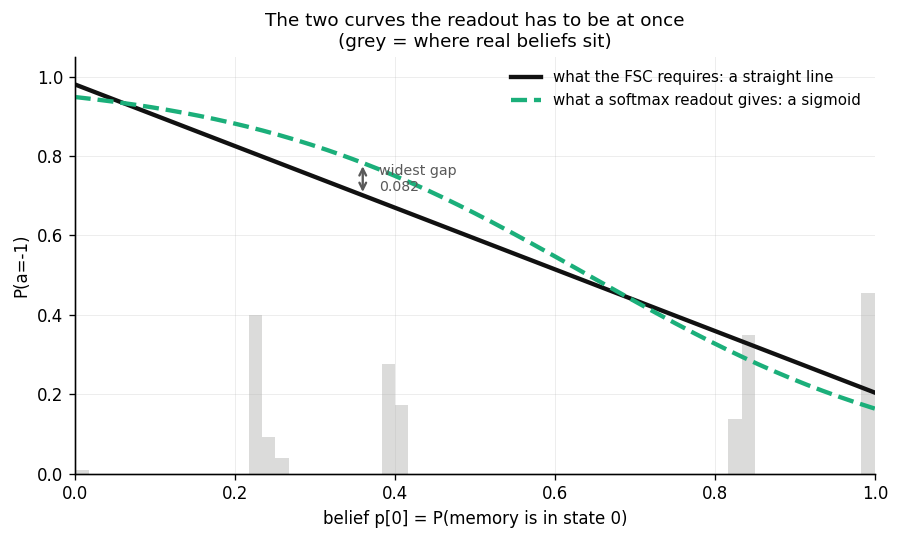

In [25]:
# --- 8.1 -- the readout wall: a straight line against a sigmoid ------------------------------
# The FSC's action probability at belief p is p @ pi, which is LINEAR in p. The network computes
# softmax(lin_W @ (E p) + lin_b). E p is affine in p, so the logit difference is affine in p,
# and a softmax of an affine function is a LOGISTIC curve. A line and a sigmoid can cross a
# couple of times; they cannot coincide. Nothing about the solve or the hidden size changes that.
P_f, E_f = FIXED[H_STAR], FIXED_E[H_STAR]
_ts = np.linspace(0, 1, 11)
print(f"   {'belief p[0]':>12}  {'FSC requires':>13}  {'network gives':>14}  {'error':>8}   what occurs here")
_bocc = np.concatenate([fsc_beliefs(FSC, s["actions"], s["observations"]) for s in SESS[:200]])
for t in _ts:
    p = np.array([t, 1 - t])
    req = float((p @ pi)[ACT_REF]); got = float(rnn_action_probs(E_f @ p, P_f)[ACT_REF])
    share = float(((_bocc[:, 0] > t - 0.05) & (_bocc[:, 0] < t + 0.05)).mean())
    print(f"   {t:>12.2f}  {req:>13.4f}  {got:>14.4f}  {abs(req-got):>8.4f}   {share:>6.1%} of trials")

# the error where the data actually is, and whether more units help
print(f"\n{'H':>3}  {'worst residual':>15}  {'readout error on REAL beliefs':>31}")
for H in H_LIST:
    ro = np.array([abs(float((p @ pi)[ACT_REF]) - float(rnn_action_probs(FIXED_E[H] @ p, FIXED[H])[ACT_REF]))
                   for p in _bocc[::37]])
    print(f"{H:>3}  {FIXED_RES[H]:>15.2e}   mean {ro.mean():>8.4f}   max {ro.max():>8.4f}")

print("\nIdentical at every hidden size, to four decimal places. If this were a capacity problem")
print("H = 4 would beat H = 1. It does not move at all, because the shape mismatch is between a")
print("straight line and a logistic curve and no number of units changes either shape.")
print("\nThis is also why the deterministic notebook never hit it: there the belief only ever sits")
print("at the two ends of this line, and a sigmoid matches a line at two points exactly. The")
print("limit was always in the architecture, with nothing in that task to expose it.")

fig, ax = plt.subplots(figsize=(7.6, 4.6))
tt = np.linspace(0, 1, 201)
# histogram on its OWN axis and drawn behind, so it cannot squash the two curves it is
# context for. Both curves live in [0, 1]; the density does not.
axb = ax.twinx()
axb.hist(_bocc[:, 0], bins=60, color=SHADE, alpha=0.30, zorder=0)
axb.set_yticks([]); axb.set_ylim(0, axb.get_ylim()[1] * 2.2)
ax.set_zorder(axb.get_zorder() + 1); ax.patch.set_visible(False)

ax.plot(tt, [(np.array([t, 1-t]) @ pi)[ACT_REF] for t in tt], color=C_FSC, lw=2.6,
        label="what the FSC requires: a straight line")
ax.plot(tt, [rnn_action_probs(E_f @ np.array([t, 1-t]), P_f)[ACT_REF] for t in tt],
        color=C_SOLVED, lw=2.6, ls="--", label="what a softmax readout gives: a sigmoid")
_worst_t = max(tt, key=lambda t: abs((np.array([t, 1-t]) @ pi)[ACT_REF]
                                     - rnn_action_probs(E_f @ np.array([t, 1-t]), P_f)[ACT_REF]))
_lo = float((np.array([_worst_t, 1-_worst_t]) @ pi)[ACT_REF])
_hi = float(rnn_action_probs(E_f @ np.array([_worst_t, 1-_worst_t]), P_f)[ACT_REF])
ax.annotate("", xy=(_worst_t, _lo), xytext=(_worst_t, _hi),
            arrowprops=dict(arrowstyle="<->", color=C_RULE, lw=1.4))
ax.text(_worst_t + 0.02, (_lo + _hi) / 2, f"widest gap\n{abs(_hi-_lo):.3f}",
        fontsize=8.5, color=C_RULE, va="center")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_xlabel("belief p[0] = P(memory is in state 0)")
ax.set_ylabel(f"P({ACT_NAME[ACT_REF]})")
ax.set_title("The two curves the readout has to be at once\n"
             "(grey = where real beliefs sit)", fontsize=11)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()

In [26]:
# --- 8.2 -- is the sigmoid forced by the GRU, or by insisting the map be linear? --------------
# Give up linearity of the embedding and choose it so the readout is exact by construction. For
# M = 2, A = 2 with one hidden unit, put the hidden coordinate at logit(P(a_ref | p)) instead of
# at p itself, then ask the GRU for the transitions in those warped coordinates.
def _logit(q): return np.log(q / (1 - q))
_W_SC, _B_SC = 4.0, 0.0                       # any scale works; it only sets the units of u
def warp(p):  return (_logit(float((p @ pi)[ACT_REF])) - _B_SC) / _W_SC

_Kw = 21
_Pg = simplex_grid(M, _Kw)
_ro = max(abs(float((p @ pi)[ACT_REF]) - 1/(1+np.exp(-(_W_SC*warp(p) + _B_SC)))) for p in _Pg)
print(f"Readout error under the warped embedding, by construction: {_ro:.2e}")

_U  = np.array([warp(p) for p in _Pg])[:, None]
_UT = np.array([[warp(belief_posterior(FSC, p, a, y)) for a in range(A) for y in range(Y)]
                for p in _Pg])
_XB = np.stack([encode_input(a, y, A, Y) for a in range(A) for y in range(Y)])
_shapes = [("W_ih", (3, A+Y)), ("b_ih", (3,)), ("W_hh", (3, 1)), ("b_hh", (3,))]
_npar = sum(int(np.prod(s)) for _, s in _shapes)
_Ut, _UTt, _XBt = map(torch.tensor, (_U, _UT, _XB))
def _unpack(th):
    o, i = {}, 0
    for k, s in _shapes:
        n = int(np.prod(s)); o[k] = th[i:i+n].reshape(s); i += n
    return o
def _res(th, lam):
    W = _unpack(th); Hb = _Ut; parts = []
    for j in range(len(_XB)):
        gi = _XBt[j] @ W["W_ih"].T + W["b_ih"]; gh = Hb @ W["W_hh"].T + W["b_hh"]
        r = torch.sigmoid(gi[:1] + gh[:, :1]); z = torch.sigmoid(gi[1:2] + gh[:, 1:2])
        n_ = torch.tanh(gi[2:] + r * gh[:, 2:])
        parts.append((((1 - z) * n_ + z * Hb) - _UTt[:, j:j+1]).reshape(-1))
    parts.append(lam * th); return torch.cat(parts)
_jf = jacrev(_res)
_f = lambda t, l: _res(torch.tensor(t), torch.tensor(l)).numpy()
_J = lambda t, l: _jf(torch.tensor(t), torch.tensor(l)).numpy()
_kw = dict(jac=_J, method="lm", xtol=1e-15, ftol=1e-15, gtol=1e-15, max_nfev=4000)
_best, _rng = None, np.random.default_rng(0)
for _ in range(4):
    th = 0.5 * _rng.standard_normal(_npar)
    th = least_squares(_f, th, args=(3e-2,),  **_kw).x
    th = least_squares(_f, th, args=(1e-12,), **_kw).x
    rr = float(np.abs(_f(th, 0.0)).max())
    if _best is None or rr < _best[0]: _best = (rr, th)
print(f"Worst TRANSITION residual in warped coordinates:            {_best[0]:.2e}")

print(f"\n{'embedding':>22}  {'readout':>10}  {'transitions':>12}   two-way map of §6")
print(f"{'linear (E p), §7':>22}  {'8e-02':>10}  {'~1e-05':>12}   exact and affine")
print(f"{'warped (logit), §8.2':>22}  {_ro:>10.0e}  {_best[0]:>12.1e}   no longer affine")
print("\nSo the sigmoid is not a limit of the GRU. It is the price of insisting that hidden state")
print("and belief be related by a matrix. Curve that relation and the readout becomes exact while")
print("the transitions give up exactness instead. The architecture can do either job; it cannot do")
print("both AND keep the linear correspondence §6 is built on.")

Readout error under the warped embedding, by construction: 1.11e-16


Worst TRANSITION residual in warped coordinates:            2.32e-03

             embedding     readout   transitions   two-way map of §6
      linear (E p), §7       8e-02        ~1e-05   exact and affine
  warped (logit), §8.2       1e-16       2.3e-03   no longer affine

So the sigmoid is not a limit of the GRU. It is the price of insisting that hidden state
and belief be related by a matrix. Curve that relation and the readout becomes exact while
the transitions give up exactness instead. The architecture can do either job; it cannot do
both AND keep the linear correspondence §6 is built on.


In [27]:
# --- 9.1 -- consolidated summary ---------------------------------------------------------------
print(f"{'':>16}  {'CE/trial':>9}  {'WS rate':>8}  {'LS rate':>8}  "
      f"{'P(stay) at k=80':>16}  {'RNN->FSC err':>13}  {'FSC->RNN err':>13}")
sw, sl = rates_from_matrix(TM["FSC"])
c, _ = ce_fsc(SESS)
print(f"{'fitted FSC':>16}  {c:>9.5f}  {sw:>8.4f}  {sl:>8.4f}  "
      f"{fsc_probe(0, WIN)[KMAX]:>16.4f}  {'(is the FSC)':>13}  {'(is the FSC)':>13}")
for tag, MODELS in (("solved", SOLVED), ("trained", TRAINED)):
    for H in H_LIST:
        P = MODELS[H]
        sw, sl = rates_from_matrix(TM[f"{tag} H={H}"])
        c, _ = ce_rnn(P, SESS)
        d = MAPFIT[(tag, H)]
        print(f"{tag+' H='+str(H):>16}  {c:>9.5f}  {sw:>8.4f}  {sl:>8.4f}  "
              f"{rnn_probe(P, 0, WIN)[KMAX]:>16.4f}  "
              f"{d['err_fwd']:>13.2e}  {d['err_bwd']:>13.2e}")
print("\nColumns 1 to 3 are on-manifold and separate nothing: every model reproduces the behavior.")
print("Columns 4 to 6 are the ones that do. The last two are the held-out affine map's largest")
print("error in each direction (§6.2); the solved networks sit at the accumulated round-off of a")
print("200-trial replay, the trained ones four hundred thousand times higher.")

                   CE/trial   WS rate   LS rate   P(stay) at k=80   RNN->FSC err   FSC->RNN err
      fitted FSC    0.56450    0.6691    0.2037            0.6700   (is the FSC)   (is the FSC)
      solved H=1    0.61695    0.7238    0.1427            0.8395       7.56e-02       6.30e-02
      solved H=2    0.61780    0.7278    0.1420            0.8441       6.27e-02       5.13e-02
      solved H=3    0.64884    0.7311    0.1447            0.8981       8.18e-02       6.88e-02
      solved H=4    0.61757    0.7278    0.1420            0.8434       6.70e-02       5.19e-02


     trained H=1    0.56482    0.6653    0.2014            0.6654       3.41e-02       3.36e-02


     trained H=2    0.56448    0.6655    0.2011            0.6635       3.49e-01       4.62e-01
     trained H=3    0.56451    0.6656    0.2026            0.6648       6.28e-02       9.33e-01
     trained H=4    0.56455    0.6656    0.2026            0.6653       7.56e-02       9.23e-01

Columns 1 to 3 are on-manifold and separate nothing: every model reproduces the behavior.
Columns 4 to 6 are the ones that do. The last two are the held-out affine map's largest
error in each direction (§6.2); the solved networks sit at the accumulated round-off of a
200-trial replay, the trained ones four hundred thousand times higher.


## 9. What this establishes

1. **The construction from the companion notebook is not wrong; it has a precondition nobody wrote
   down.** It requires the controller's belief to visit only the points the requirements pin. A
   deterministic machine satisfies that automatically, sitting on a corner 100% of the time. This
   machine sits on one 18% of the time, and the construction is unconstrained over the rest (§3.3).

2. **Solving exactly is not the same as being the machine.** §2 hits every requirement at machine
   precision, $10^{-16}$, and its state still sits $10^{-2}$ from the controller's over real
   sessions. A finite list of conditions pins a network only where the conditions are.

3. **The memory transfers, once you ask properly.** Stating the requirement along the belief line
   rather than at its two ends, and targeting the Bayesian posterior rather than the forward
   transition, drops the tracking error by about 3500x to $10^{-6}$ (§7.2). It needs about 11
   belief points and stops improving after that, and the error at beliefs between grid points
   matches the error at grid points, so the network holds the rule rather than the samples (§7.3).
   $H = 1$ is enough, as on the deterministic task.

4. **The readout and the memory cannot both be exact under a linear map.** The controller's
   action probability is linear in the belief; a softmax over a *linear* embedding is a sigmoid,
   and the two agree at a couple of points and nowhere else, the gap reaching 0.08 across the
   beliefs that occur and identical at $H = 1$ and $H = 4$ (§8.1). That shape is not a limit of
   the GRU, though. Warp the embedding so the readout is right by construction and it becomes
   exact to $10^{-16}$, while the transitions give up exactness instead (§8.2). The architecture
   can do either job; it cannot do both while keeping the linear hidden-state-to-belief map that
   §6 depends on.

5. **On this task a trained network beats the exact construction.** Cross-entropy per trial: the
   FSC 0.5655, the best trained network 0.5655, the repaired construction 0.5762, the original
   construction 0.6195. Training is not bound to place the memory states linearly, so its readout
   is not forced into the wrong shape. That inverts the deterministic result, where the
   construction was exact and training drifted.

6. **Two different failures wear the same clothes.** The trained GRU in
   `rnn_offmanifold_finding.ipynb` is right where the data is and wrong outside it. The §2
   construction here is right where its requirements are and wrong outside them. Neither is a
   capacity problem, and both look like a network that has learned the rule until you measure it
   somewhere nobody constrained.

### What this does not establish

- The §7 grid is written for $M = 2$, a segment. Larger $M$ needs a simplex grid, which is a
  change of sampling rather than of method, but it is not verified here.
- The §8 wall applies to this readout, a softmax over an affine function of the hidden state,
  which is what tinyRNN uses. A different readout could match a linear-in-belief policy; whether
  any architecture in common use does is not addressed.
- Nothing here says the repaired construction is the network training would find, or that it is
  unique. It is one exact solution among many, chosen for small weights.